## Load Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import ast
import re
import pickle
import warnings

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Load Dataset

In [3]:
movies = pd.read_csv("tmdb_5000_movies.csv")

print("Movies dataset loaded successfully!")
print("Shape:", movies.shape)

Movies dataset loaded successfully!
Shape: (4803, 20)


In [4]:
credits = pd.read_csv("tmdb_5000_credits.csv")

print("Credits dataset loaded successfully!")
print("Shape:", credits.shape)

Credits dataset loaded successfully!
Shape: (4803, 4)


## First Look 

In [5]:
print("MOVIES DATASET")
display(movies.head())

MOVIES DATASET


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [6]:
print("CREDITS DATASET")
display(credits.head())

CREDITS DATASET


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## Basic Inspection

In [7]:
print("Movies:")
print("Rows    :", movies.shape[0])
print("Columns :", movies.shape[1])

print("\nCredits:")
print("Rows    :", credits.shape[0])
print("Columns :", credits.shape[1])

Movies:
Rows    : 4803
Columns : 20

Credits:
Rows    : 4803
Columns : 4


In [8]:
print("Movies Columns:\n")

for i, column in enumerate(movies.columns, start=1):
    print(i, "→", column)

Movies Columns:

1 → budget
2 → genres
3 → homepage
4 → id
5 → keywords
6 → original_language
7 → original_title
8 → overview
9 → popularity
10 → production_companies
11 → production_countries
12 → release_date
13 → revenue
14 → runtime
15 → spoken_languages
16 → status
17 → tagline
18 → title
19 → vote_average
20 → vote_count


In [9]:
print("\nCredits Columns:\n")

for i, column in enumerate(credits.columns, start=1):
    print(i, "→", column)


Credits Columns:

1 → movie_id
2 → title
3 → cast
4 → crew


In [10]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [11]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


## Missing Values

In [12]:
print("Movies Missing Values:")
display(movies.isnull().sum().sort_values)

Movies Missing Values:


<bound method Series.sort_values of budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64>

In [13]:
print("Credits Missing Values:")
display(credits.isnull().sum().sort_values)

Credits Missing Values:


<bound method Series.sort_values of movie_id    0
title       0
cast        0
crew        0
dtype: int64>

## Duplicated Value

In [14]:
print("Movies duplicate rows  :", movies.duplicated().sum())
print("Credits duplicate rows :", credits.duplicated().sum())

Movies duplicate rows  : 0
Credits duplicate rows : 0


In [15]:
movies.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [16]:
print("Total movie records :", len(movies))
print("Unique movie IDs    :", movies["id"].nunique())
print("Unique movie titles :", movies["title"].nunique())

Total movie records : 4803
Unique movie IDs    : 4803
Unique movie titles : 4800


In [17]:
missing_percentage = (
    movies.isnull().sum() / len(movies) * 100
).sort_values(ascending=False)

missing_percentage

homepage                64.355611
tagline                 17.572351
overview                 0.062461
runtime                  0.041641
release_date             0.020820
budget                   0.000000
vote_average             0.000000
title                    0.000000
status                   0.000000
spoken_languages         0.000000
revenue                  0.000000
production_countries     0.000000
genres                   0.000000
production_companies     0.000000
popularity               0.000000
original_title           0.000000
original_language        0.000000
keywords                 0.000000
id                       0.000000
vote_count               0.000000
dtype: float64

In [18]:
missing_percentage[missing_percentage > 0]

homepage        64.355611
tagline         17.572351
overview         0.062461
runtime          0.041641
release_date     0.020820
dtype: float64

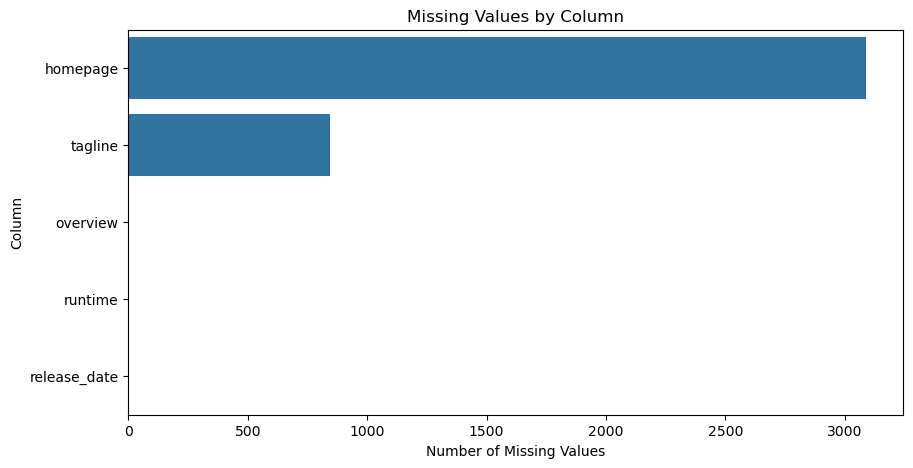

In [19]:
missing = (
    movies.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.show()

In [20]:
duplicate_count = movies.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [21]:
duplicate_count_credits = credits.duplicated().sum()

print("Duplicate rows in credits:", duplicate_count_credits)

Duplicate rows in credits: 0


In [22]:
recommendation_columns = [
    "title",
    "genres",
    "keywords",
    "overview"
]

movies[recommendation_columns].head()

,title,genres,keywords,overview
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha..."
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",Following the death of District Attorney Harve...
4,John Carter,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","John Carter is a war-weary, former military ca..."


In [23]:
credits[["title", "cast", "crew"]].head()

,title,cast,crew
0,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [24]:
feature_groups = {
    "recommendation": [
        "genres",
        "keywords",
        "overview",
        "cast",
        "director"
    ],
    
    "ranking": [
        "vote_average",
        "vote_count",
        "popularity"
    ],
    
    "temporal": [
        "release_date"
    ],
    
    "identity": [
        "id",
        "title"
    ]
}

for group, columns in feature_groups.items():
    print(f"\n{group.upper()}")
    for column in columns:
        print(" →", column)


RECOMMENDATION
 → genres
 → keywords
 → overview
 → cast
 → director

RANKING
 → vote_average
 → vote_count
 → popularity

TEMPORAL
 → release_date

IDENTITY
 → id
 → title


In [25]:
movies_clean = movies.copy()
credits_clean = credits.copy()

print("Working copies created successfully.")

print("Movies:", movies_clean.shape)
print("Credits:", credits_clean.shape)

Working copies created successfully.
Movies: (4803, 20)
Credits: (4803, 4)


In [26]:
print("Movies duplicates :", movies_clean.duplicated().sum())
print("Credits duplicates:", credits_clean.duplicated().sum())

Movies duplicates : 0
Credits duplicates: 0


In [27]:
movies_clean = movies_clean.drop_duplicates().reset_index(drop=True)
credits_clean = credits_clean.drop_duplicates().reset_index(drop=True)

In [28]:
print("Movies shape after duplicate handling :", movies_clean.shape)
print("Credits shape after duplicate handling:", credits_clean.shape)

Movies shape after duplicate handling : (4803, 20)
Credits shape after duplicate handling: (4803, 4)


In [29]:
missing_movies = (
    movies_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing_movies[missing_movies > 0])

homepage        3091
tagline          844
overview           3
runtime            2
release_date       1
dtype: int64

In [30]:
missing_credits = (
    credits_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing_credits[missing_credits > 0])

Series([], dtype: int64)

In [31]:
text_columns = [
    "genres",
    "keywords",
    "overview"
]

for col in text_columns:
    movies_clean[col] = movies_clean[col].fillna("")

In [32]:
credits_clean["cast"] = credits_clean["cast"].fillna("[]")
credits_clean["crew"] = credits_clean["crew"].fillna("[]")

In [33]:
ranking_columns = [
    "vote_average",
    "vote_count",
    "popularity"
]

display(movies_clean[ranking_columns].isnull().sum())

vote_average    0
vote_count      0
popularity      0
dtype: int64

In [34]:
movies_clean[ranking_columns].describe()

,vote_average,vote_count,popularity
count,4803.000000,4803.000000,4803.000000
mean,6.092172,690.217989,21.492301
std,1.194612,1234.585891,31.816650
min,0.000000,0.000000,0.000000
25%,5.600000,54.000000,4.668070
50%,6.200000,235.000000,12.921594
75%,6.800000,737.000000,28.313505
max,10.000000,13752.000000,875.581305


In [35]:
movies_clean.dtypes

budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object

In [36]:
movies_clean["release_date"] = pd.to_datetime(
    movies_clean["release_date"],
    errors="coerce"
)

In [37]:
print(movies_clean["release_date"].dtype)

datetime64[ns]


In [38]:
movies_clean["release_year"] = (
    movies_clean["release_date"].dt.year
)

In [39]:
movies_clean[
    ["title", "release_date", "release_year"]
].head()

,title,release_date,release_year
0,Avatar,2009-12-10,2009.0
1,Pirates of the Caribbean: At World's End,2007-05-19,2007.0
2,Spectre,2015-10-26,2015.0
3,The Dark Knight Rises,2012-07-16,2012.0
4,John Carter,2012-03-07,2012.0


In [40]:
print("Negative budget:",
      (movies_clean["budget"] < 0).sum())

print("Negative revenue:",
      (movies_clean["revenue"] < 0).sum())

print("Negative runtime:",
      (movies_clean["runtime"] < 0).sum())

print("Negative vote count:",
      (movies_clean["vote_count"] < 0).sum())

Negative budget: 0
Negative revenue: 0
Negative runtime: 0
Negative vote count: 0


In [41]:
invalid_ratings = movies_clean[
    (movies_clean["vote_average"] < 0) |
    (movies_clean["vote_average"] > 10)
]

print("Invalid ratings:", len(invalid_ratings))

Invalid ratings: 0


In [42]:
invalid_votes = movies_clean[
    movies_clean["vote_count"] < 0
]

print("Invalid vote counts:", len(invalid_votes))

Invalid vote counts: 0


In [43]:
invalid_popularity = movies_clean[
    movies_clean["popularity"] < 0
]

print("Invalid popularity values:",
      len(invalid_popularity))

Invalid popularity values: 0


In [44]:
def parse_data(value):
    """
    Convert a structured string into a Python object.
    Returns an empty list if parsing fails.
    """
    
    if pd.isna(value):
        return []
    
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []

In [45]:
test_value = movies_clean.loc[0, "genres"]

print("Original:")
print(test_value)

print("\nParsed:")
print(parse_data(test_value))

Original:
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]

Parsed:
[{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 878, 'name': 'Science Fiction'}]


## Extract Genres

In [46]:
def extract_names(value):
    data = parse_data(value)
    
    if not isinstance(data, list):
        return []
    
    return [
        item["name"].replace(" ", "_").lower()
        for item in data
        if isinstance(item, dict) and "name" in item
    ]

In [47]:
extract_names(movies_clean.loc[0, "genres"])

['action', 'adventure', 'fantasy', 'science_fiction']

In [48]:
movies_clean["genres_list"] = movies_clean["genres"].apply(
    extract_names
)

In [49]:
movies_clean["keywords_list"] = movies_clean["keywords"].apply(
    extract_names
)

In [50]:
movies_clean[
    ["title", "keywords_list"]
].head()

,title,keywords_list
0,Avatar,"[culture_clash, future, space_war, space_colon..."
1,Pirates of the Caribbean: At World's End,"[ocean, drug_abuse, exotic_island, east_india_..."
2,Spectre,"[spy, based_on_novel, secret_agent, sequel, mi..."
3,The Dark Knight Rises,"[dc_comics, crime_fighter, terrorist, secret_i..."
4,John Carter,"[based_on_novel, mars, medallion, space_travel..."


In [51]:
credits_clean["cast_list"] = credits_clean["cast"].apply(
    parse_data
)

credits_clean["crew_list"] = credits_clean["crew"].apply(
    parse_data
)

In [52]:
credits_clean[
    ["title", "cast_list", "crew_list"]
].head(1)

,title,cast_list,crew_list
0,Avatar,"[{'cast_id': 242, 'character': 'Jake Sully', '...","[{'credit_id': '52fe48009251416c750aca23', 'de..."


## Extract Top Cast

In [53]:
def extract_cast(cast_data, n=5):
    
    if not isinstance(cast_data, list):
        return []
    
    result = []
    
    for actor in cast_data[:n]:
        if isinstance(actor, dict) and "name" in actor:
            name = actor["name"]
            result.append(name.replace(" ", "_").lower())
    
    return result

In [54]:
credits_clean["cast_names"] = credits_clean["cast_list"].apply(
    extract_cast
)

In [55]:
credits_clean[
    ["title", "cast_names"]
].head()

,title,cast_names
0,Avatar,"[sam_worthington, zoe_saldana, sigourney_weave..."
1,Pirates of the Caribbean: At World's End,"[johnny_depp, orlando_bloom, keira_knightley, ..."
2,Spectre,"[daniel_craig, christoph_waltz, léa_seydoux, r..."
3,The Dark Knight Rises,"[christian_bale, michael_caine, gary_oldman, a..."
4,John Carter,"[taylor_kitsch, lynn_collins, samantha_morton,..."


## Extract Director

In [56]:
def extract_director(crew_data):
    
    if not isinstance(crew_data, list):
        return ""
    
    for person in crew_data:
        if (
            isinstance(person, dict)
            and person.get("job") == "Director"
        ):
            return person.get("name", "").replace(
                " ", "_"
            ).lower()
    
    return ""

In [57]:
credits_clean["director"] = credits_clean["crew_list"].apply(
    extract_director
)

In [58]:
credits_clean[
    ["title", "director"]
].head(10)

,title,director
0,Avatar,james_cameron
1,Pirates of the Caribbean: At World's End,gore_verbinski
2,Spectre,sam_mendes
3,The Dark Knight Rises,christopher_nolan
4,John Carter,andrew_stanton
5,Spider-Man 3,sam_raimi
6,Tangled,byron_howard
7,Avengers: Age of Ultron,joss_whedon
8,Harry Potter and the Half-Blood Prince,david_yates
9,Batman v Superman: Dawn of Justice,zack_snyder


In [59]:
credits_features = credits_clean[
    [
        "movie_id",
        "title",
        "cast_names",
        "director"
    ]
].copy()

In [60]:
credits_features.head()

,movie_id,title,cast_names,director
0,19995,Avatar,"[sam_worthington, zoe_saldana, sigourney_weave...",james_cameron
1,285,Pirates of the Caribbean: At World's End,"[johnny_depp, orlando_bloom, keira_knightley, ...",gore_verbinski
2,206647,Spectre,"[daniel_craig, christoph_waltz, léa_seydoux, r...",sam_mendes
3,49026,The Dark Knight Rises,"[christian_bale, michael_caine, gary_oldman, a...",christopher_nolan
4,49529,John Carter,"[taylor_kitsch, lynn_collins, samantha_morton,...",andrew_stanton


## Merge Movies and Credits

In [61]:
movies_merged = movies_clean.merge(
    credits_features,
    left_on="id",
    right_on="movie_id",
    how="left",
    suffixes=("", "_credits")
)

In [62]:
print("Merged dataset shape:", movies_merged.shape)

Merged dataset shape: (4803, 27)


In [63]:
movies_merged[
    [
        "id",
        "title",
        "genres_list",
        "keywords_list",
        "cast_names",
        "director"
    ]
].head()

,id,title,genres_list,keywords_list,cast_names,director
0,19995,Avatar,"[action, adventure, fantasy, science_fiction]","[culture_clash, future, space_war, space_colon...","[sam_worthington, zoe_saldana, sigourney_weave...",james_cameron
1,285,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[ocean, drug_abuse, exotic_island, east_india_...","[johnny_depp, orlando_bloom, keira_knightley, ...",gore_verbinski
2,206647,Spectre,"[action, adventure, crime]","[spy, based_on_novel, secret_agent, sequel, mi...","[daniel_craig, christoph_waltz, léa_seydoux, r...",sam_mendes
3,49026,The Dark Knight Rises,"[action, crime, drama, thriller]","[dc_comics, crime_fighter, terrorist, secret_i...","[christian_bale, michael_caine, gary_oldman, a...",christopher_nolan
4,49529,John Carter,"[action, adventure, science_fiction]","[based_on_novel, mars, medallion, space_travel...","[taylor_kitsch, lynn_collins, samantha_morton,...",andrew_stanton


In [64]:
print(
    "Missing genres:",
    movies_merged["genres_list"].apply(len).eq(0).sum()
)

print(
    "Missing keywords:",
    movies_merged["keywords_list"].apply(len).eq(0).sum()
)

print(
    "Missing cast:",
    movies_merged["cast_names"].apply(len).eq(0).sum()
)

print(
    "Missing director:",
    movies_merged["director"].eq("").sum()
)

Missing genres: 28
Missing keywords: 412
Missing cast: 43
Missing director: 30


In [65]:
recommendation_df = movies_merged[
    [
        "id",
        "title",
        "genres_list",
        "keywords_list",
        "overview",
        "cast_names",
        "director",
        "vote_average",
        "vote_count",
        "popularity",
        "release_date",
        "release_year",
        "original_language"
    ]
].copy()

In [66]:
recommendation_df.head()

,id,title,genres_list,keywords_list,overview,cast_names,director,vote_average,vote_count,popularity,release_date,release_year,original_language
0,19995,Avatar,"[action, adventure, fantasy, science_fiction]","[culture_clash, future, space_war, space_colon...","In the 22nd century, a paraplegic Marine is di...","[sam_worthington, zoe_saldana, sigourney_weave...",james_cameron,7.2,11800,150.437577,2009-12-10,2009.0,en
1,285,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[ocean, drug_abuse, exotic_island, east_india_...","Captain Barbossa, long believed to be dead, ha...","[johnny_depp, orlando_bloom, keira_knightley, ...",gore_verbinski,6.9,4500,139.082615,2007-05-19,2007.0,en
2,206647,Spectre,"[action, adventure, crime]","[spy, based_on_novel, secret_agent, sequel, mi...",A cryptic message from Bond’s past sends him o...,"[daniel_craig, christoph_waltz, léa_seydoux, r...",sam_mendes,6.3,4466,107.376788,2015-10-26,2015.0,en
3,49026,The Dark Knight Rises,"[action, crime, drama, thriller]","[dc_comics, crime_fighter, terrorist, secret_i...",Following the death of District Attorney Harve...,"[christian_bale, michael_caine, gary_oldman, a...",christopher_nolan,7.6,9106,112.312950,2012-07-16,2012.0,en
4,49529,John Carter,"[action, adventure, science_fiction]","[based_on_novel, mars, medallion, space_travel...","John Carter is a war-weary, former military ca...","[taylor_kitsch, lynn_collins, samantha_morton,...",andrew_stanton,6.1,2124,43.926995,2012-03-07,2012.0,en


## Text Normalization

In [67]:
def normalize_text(text):
    
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    
    # Replace non-alphanumeric characters with spaces
    text = re.sub(r"[^a-z0-9_ ]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [68]:
sample_text = "Science-Fiction, Adventure & Space!"

print("Before :", sample_text)
print("After  :", normalize_text(sample_text))

Before : Science-Fiction, Adventure & Space!
After  : science fiction adventure space


In [69]:
recommendation_df["overview_clean"] = (
    recommendation_df["overview"]
    .apply(normalize_text)
)

In [70]:
recommendation_df[
    ["title", "overview", "overview_clean"]
].head()

,title,overview,overview_clean
0,Avatar,"In the 22nd century, a paraplegic Marine is di...",in the 22nd century a paraplegic marine is dis...
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",captain barbossa long believed to be dead has ...
2,Spectre,A cryptic message from Bond’s past sends him o...,a cryptic message from bond s past sends him o...
3,The Dark Knight Rises,Following the death of District Attorney Harve...,following the death of district attorney harve...
4,John Carter,"John Carter is a war-weary, former military ca...",john carter is a war weary former military cap...


## Convert List to Text

In [73]:
def list_to_text(items):
    
    if not isinstance(items, list):
        return ""
    
    return " ".join(
        str(item).lower().strip()
        for item in items
        if item
    )

In [74]:
recommendation_df["genres_text"] = (
    recommendation_df["genres_list"]
    .apply(list_to_text)
)

In [75]:
recommendation_df[
    ["title", "genres_list", "genres_text"]
].head()

,title,genres_list,genres_text
0,Avatar,"[action, adventure, fantasy, science_fiction]",action adventure fantasy science_fiction
1,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]",adventure fantasy action
2,Spectre,"[action, adventure, crime]",action adventure crime
3,The Dark Knight Rises,"[action, crime, drama, thriller]",action crime drama thriller
4,John Carter,"[action, adventure, science_fiction]",action adventure science_fiction


In [76]:
recommendation_df["keywords_text"] = (
    recommendation_df["keywords_list"]
    .apply(list_to_text)
)

In [77]:
recommendation_df["cast_text"] = (
    recommendation_df["cast_names"]
    .apply(list_to_text)
)

In [78]:
recommendation_df["director_text"] = (
    recommendation_df["director"]
    .apply(normalize_text)
)

## Combined Features

In [79]:
recommendation_df["combined_features"] = (
    recommendation_df["genres_text"] + " " +
    recommendation_df["keywords_text"] + " " +
    recommendation_df["overview_clean"] + " " +
    recommendation_df["cast_text"] + " " +
    recommendation_df["director_text"]
).str.strip()

In [80]:
recommendation_df[
    [
        "title",
        "genres_text",
        "keywords_text",
        "cast_text",
        "director_text",
        "combined_features"
    ]
].head(3)

,title,genres_text,keywords_text,cast_text,director_text,combined_features
0,Avatar,action adventure fantasy science_fiction,culture_clash future space_war space_colony so...,sam_worthington zoe_saldana sigourney_weaver s...,james_cameron,action adventure fantasy science_fiction cultu...
1,Pirates of the Caribbean: At World's End,adventure fantasy action,ocean drug_abuse exotic_island east_india_trad...,johnny_depp orlando_bloom keira_knightley stel...,gore_verbinski,adventure fantasy action ocean drug_abuse exot...
2,Spectre,action adventure crime,spy based_on_novel secret_agent sequel mi6 bri...,daniel_craig christoph_waltz léa_seydoux ralph...,sam_mendes,action adventure crime spy based_on_novel secr...


In [81]:
empty_features = recommendation_df[
    recommendation_df["combined_features"].str.strip() == ""
]

print("Movies with empty combined features:",
      len(empty_features))

Movies with empty combined features: 0


In [82]:
recommendation_df["feature_length"] = (
    recommendation_df["combined_features"]
    .str.split()
    .str.len()
)

recommendation_df["feature_length"].describe()

count    4803.000000
mean       69.518010
std        29.357351
min         2.000000
25%        47.000000
50%        66.000000
75%        85.000000
max       209.000000
Name: feature_length, dtype: float64

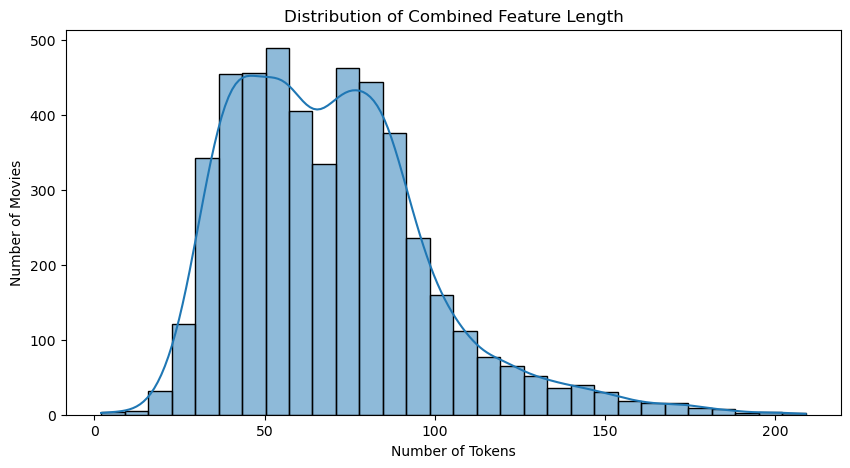

In [83]:
plt.figure(figsize=(10, 5))

sns.histplot(
    recommendation_df["feature_length"],
    bins=30,
    kde=True
)

plt.title("Distribution of Combined Feature Length")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Movies")

plt.show()

In [84]:
final_columns = [
    "id",
    "title",
    "genres_list",
    "keywords_list",
    "overview_clean",
    "cast_names",
    "director",
    "vote_average",
    "vote_count",
    "popularity",
    "release_date",
    "release_year",
    "original_language",
    "combined_features"
]

recommendation_df = recommendation_df[final_columns].copy()

print("Final recommendation dataset shape:")
print(recommendation_df.shape)

display(recommendation_df.head())

Final recommendation dataset shape:
(4803, 14)


,id,title,genres_list,keywords_list,overview_clean,cast_names,director,vote_average,vote_count,popularity,release_date,release_year,original_language,combined_features
0,19995,Avatar,"[action, adventure, fantasy, science_fiction]","[culture_clash, future, space_war, space_colon...",in the 22nd century a paraplegic marine is dis...,"[sam_worthington, zoe_saldana, sigourney_weave...",james_cameron,7.2,11800,150.437577,2009-12-10,2009.0,en,action adventure fantasy science_fiction cultu...
1,285,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[ocean, drug_abuse, exotic_island, east_india_...",captain barbossa long believed to be dead has ...,"[johnny_depp, orlando_bloom, keira_knightley, ...",gore_verbinski,6.9,4500,139.082615,2007-05-19,2007.0,en,adventure fantasy action ocean drug_abuse exot...
2,206647,Spectre,"[action, adventure, crime]","[spy, based_on_novel, secret_agent, sequel, mi...",a cryptic message from bond s past sends him o...,"[daniel_craig, christoph_waltz, léa_seydoux, r...",sam_mendes,6.3,4466,107.376788,2015-10-26,2015.0,en,action adventure crime spy based_on_novel secr...
3,49026,The Dark Knight Rises,"[action, crime, drama, thriller]","[dc_comics, crime_fighter, terrorist, secret_i...",following the death of district attorney harve...,"[christian_bale, michael_caine, gary_oldman, a...",christopher_nolan,7.6,9106,112.312950,2012-07-16,2012.0,en,action crime drama thriller dc_comics crime_fi...
4,49529,John Carter,"[action, adventure, science_fiction]","[based_on_novel, mars, medallion, space_travel...",john carter is a war weary former military cap...,"[taylor_kitsch, lynn_collins, samantha_morton,...",andrew_stanton,6.1,2124,43.926995,2012-03-07,2012.0,en,action adventure science_fiction based_on_nove...


## Basic Feature Statistics

In [85]:
print("Total Movies:", len(recommendation_df))

print(
    "Empty Combined Features:",
    recommendation_df["combined_features"]
    .str.strip()
    .eq("")
    .sum()
)

print(
    "Missing Combined Features:",
    recommendation_df["combined_features"]
    .isnull()
    .sum()
)

print(
    "Duplicate Movie Titles:",
    recommendation_df["title"]
    .duplicated()
    .sum()
)

Total Movies: 4803
Empty Combined Features: 0
Missing Combined Features: 0
Duplicate Movie Titles: 3


## Feature Length

In [86]:
recommendation_df["feature_length"] = (
    recommendation_df["combined_features"]
    .str.split()
    .str.len()
)

print(
    recommendation_df["feature_length"]
    .describe()
)

count    4803.000000
mean       69.518010
std        29.357351
min         2.000000
25%        47.000000
50%        66.000000
75%        85.000000
max       209.000000
Name: feature_length, dtype: float64


## Movies with very little metadata

In [87]:
short_features = recommendation_df[
    recommendation_df["feature_length"] < 5
]

print(
    "Movies with fewer than 5 tokens:",
    len(short_features)
)

Movies with fewer than 5 tokens: 3


In [88]:
short_features[
    ["title", "combined_features"]
].head(10)

,title,combined_features
4401,The Helix... Loaded,action comedy science_fiction
4431,Food Chains,documentary sanjay_rawal
4458,Harrison Montgomery,film from daniel davila


In [89]:
long_features = recommendation_df[
    recommendation_df["feature_length"] > 300
]

print(
    "Movies with more than 300 tokens:",
    len(long_features)
)

Movies with more than 300 tokens: 0


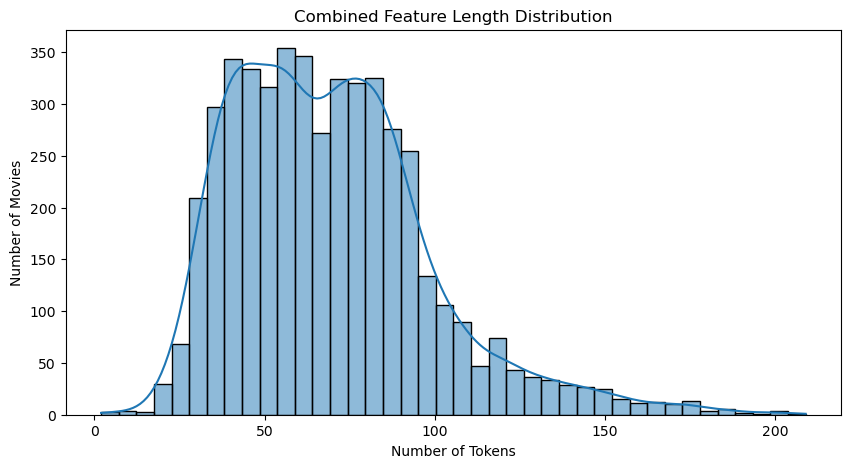

In [90]:
plt.figure(figsize=(10, 5))

sns.histplot(
    recommendation_df["feature_length"],
    bins=40,
    kde=True
)

plt.title("Combined Feature Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Movies")

plt.show()

## Genre Frequency

In [91]:
from collections import Counter

genre_counter = Counter(
    genre
    for genre_list in recommendation_df["genres_list"]
    for genre in genre_list
)

genre_counts = pd.DataFrame(
    genre_counter.most_common(),
    columns=["genre", "movie_count"]
)

genre_counts.head(15)

,genre,movie_count
0,drama,2297
1,comedy,1722
2,thriller,1274
3,action,1154
4,romance,894
5,adventure,790
6,crime,696
7,science_fiction,535
8,horror,519
9,family,513


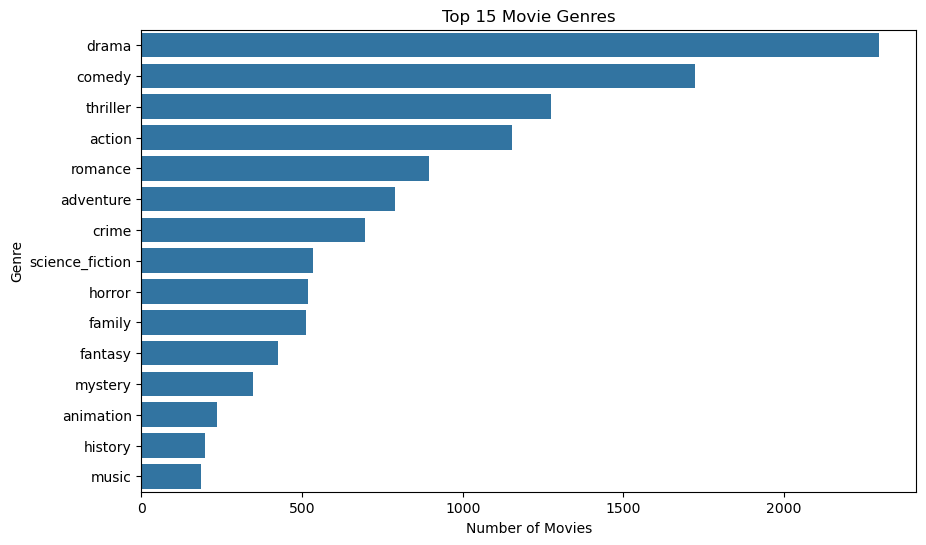

In [92]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_counts.head(15),
    x="movie_count",
    y="genre"
)

plt.title("Top 15 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

## Keyword Frequency

In [93]:
keyword_counter = Counter(
    keyword
    for keyword_list in recommendation_df["keywords_list"]
    for keyword in keyword_list
)

keyword_counts = pd.DataFrame(
    keyword_counter.most_common(20),
    columns=["keyword", "movie_count"]
)

keyword_counts.head(20)

,keyword,movie_count
0,woman_director,324
1,independent_film,318
2,duringcreditsstinger,307
3,based_on_novel,197
4,murder,189
5,aftercreditsstinger,170
6,violence,150
7,dystopia,139
8,sport,126
9,revenge,118


## Cast Frequency

In [94]:
cast_counter = Counter(
    actor
    for cast_list in recommendation_df["cast_names"]
    for actor in cast_list
)

cast_counts = pd.DataFrame(
    cast_counter.most_common(20),
    columns=["actor", "movie_count"]
)

cast_counts.head(20)

,actor,movie_count
0,robert_de_niro,54
1,samuel_l._jackson,44
2,bruce_willis,39
3,matt_damon,36
4,nicolas_cage,35
5,morgan_freeman,35
6,johnny_depp,32
7,brad_pitt,32
8,mark_wahlberg,31
9,owen_wilson,31


## Director Frequency

In [95]:
director_counts = (
    recommendation_df[
        recommendation_df["director"].str.strip() != ""
    ]["director"]
    .value_counts()
    .reset_index()
)

director_counts.columns = [
    "director",
    "movie_count"
]

director_counts.head(20)

,director,movie_count
0,steven_spielberg,27
1,woody_allen,21
2,martin_scorsese,20
3,clint_eastwood,20
4,ridley_scott,16
5,spike_lee,16
6,robert_rodriguez,16
7,steven_soderbergh,15
8,renny_harlin,15
9,oliver_stone,14


## Metadata Coverage

In [96]:
coverage = pd.DataFrame({
    "Feature": [
        "Genres",
        "Keywords",
        "Overview",
        "Cast",
        "Director"
    ],
    
    "Available": [
        recommendation_df["genres_list"].apply(len).gt(0).sum(),
        recommendation_df["keywords_list"].apply(len).gt(0).sum(),
        recommendation_df["overview_clean"].str.strip().ne("").sum(),
        recommendation_df["cast_names"].apply(len).gt(0).sum(),
        recommendation_df["director"].str.strip().ne("").sum()
    ]
})

coverage["Coverage_%"] = (
    coverage["Available"]
    / len(recommendation_df)
    * 100
)

coverage

,Feature,Available,Coverage_%
0,Genres,4775,99.417031
1,Keywords,4391,91.422028
2,Overview,4799,99.916719
3,Cast,4760,99.104726
4,Director,4773,99.375390


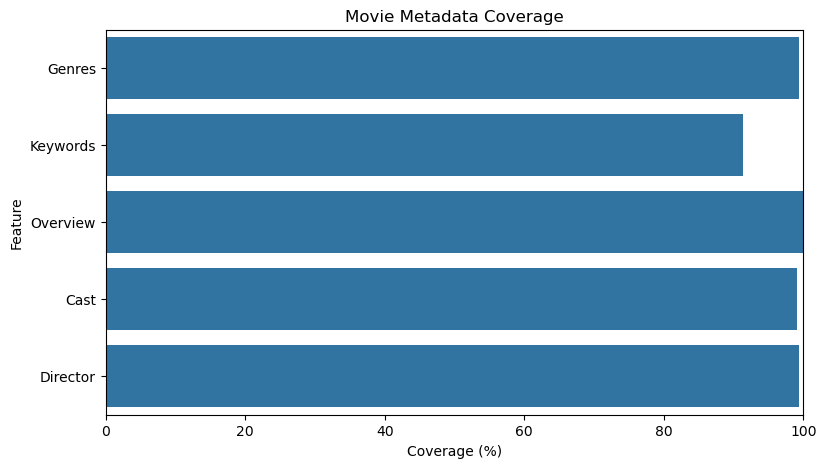

In [97]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=coverage,
    x="Coverage_%",
    y="Feature"
)

plt.title("Movie Metadata Coverage")
plt.xlabel("Coverage (%)")
plt.ylabel("Feature")

plt.xlim(0, 100)

plt.show()

## Metadata Availability Feature

In [98]:
recommendation_df["has_genres"] = (
    recommendation_df["genres_list"]
    .apply(len)
    .gt(0)
)

recommendation_df["has_keywords"] = (
    recommendation_df["keywords_list"]
    .apply(len)
    .gt(0)
)

recommendation_df["has_cast"] = (
    recommendation_df["cast_names"]
    .apply(len)
    .gt(0)
)

recommendation_df["has_director"] = (
    recommendation_df["director"]
    .str.strip()
    .ne("")
)

recommendation_df["has_overview"] = (
    recommendation_df["overview_clean"]
    .str.strip()
    .ne("")
)

In [99]:
recommendation_df[
    [
        "has_genres",
        "has_keywords",
        "has_cast",
        "has_director",
        "has_overview",
        "vote_average",
        "popularity"
    ]
].head()

,has_genres,has_keywords,has_cast,has_director,has_overview,vote_average,popularity
0,True,True,True,True,True,7.2,150.437577
1,True,True,True,True,True,6.9,139.082615
2,True,True,True,True,True,6.3,107.376788
3,True,True,True,True,True,7.6,112.312950
4,True,True,True,True,True,6.1,43.926995


## Dataset Overview

In [100]:
print("Total Movies:", len(recommendation_df))

print(
    "Average Rating:",
    round(recommendation_df["vote_average"].mean(), 2)
)

print(
    "Average Popularity:",
    round(recommendation_df["popularity"].mean(), 2)
)

print(
    "Average Vote Count:",
    round(recommendation_df["vote_count"].mean(), 2)
)

Total Movies: 4803
Average Rating: 6.09
Average Popularity: 21.49
Average Vote Count: 690.22


## Rating Distribution

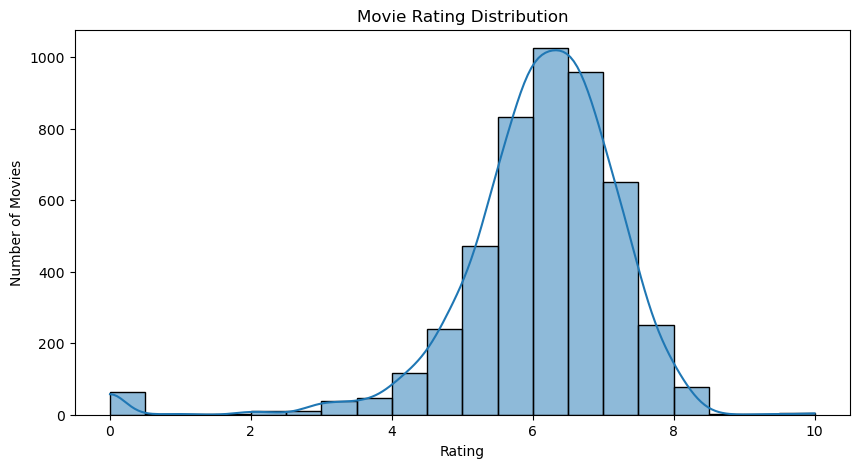

In [101]:
plt.figure(figsize=(10, 5))

sns.histplot(
    recommendation_df["vote_average"],
    bins=20,
    kde=True
)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")

plt.show()

## Movies By Relase Year

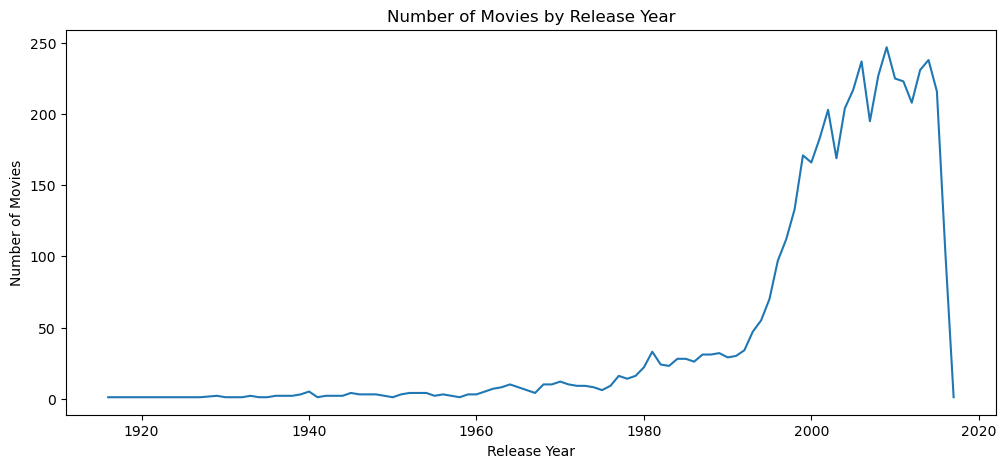

In [102]:
year_counts = (
    recommendation_df
    .dropna(subset=["release_year"])
    .groupby("release_year")
    .size()
)

plt.figure(figsize=(12, 5))

plt.plot(
    year_counts.index,
    year_counts.values
)

plt.title("Number of Movies by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.show()

## Genre Distribution

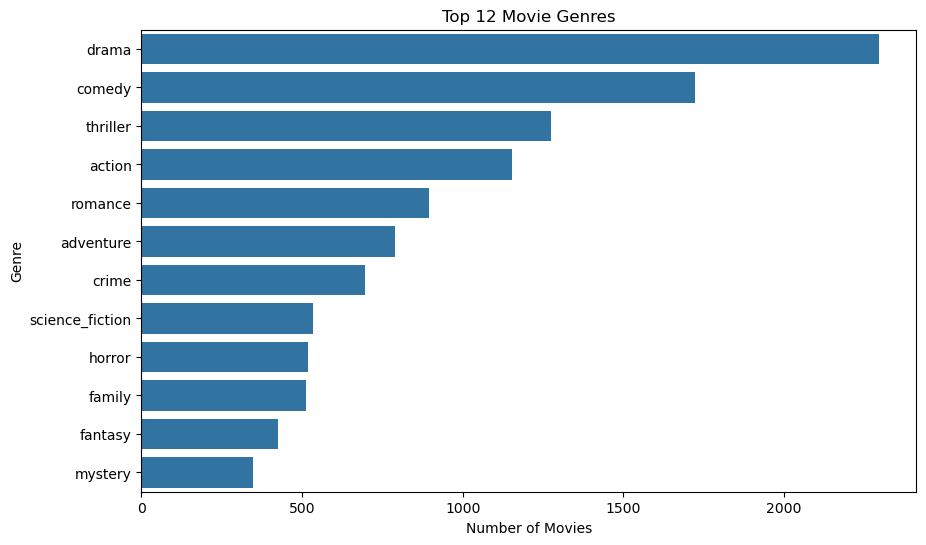

In [103]:
genre_counts = (
    genre_counts
    .sort_values("movie_count", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_counts.head(12),
    x="movie_count",
    y="genre"
)

plt.title("Top 12 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

## Popularity VS Rating

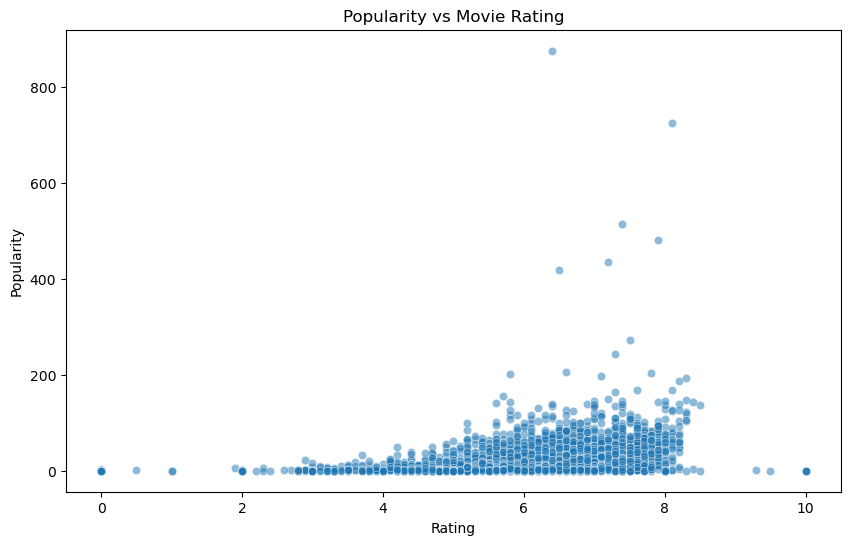

In [105]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=recommendation_df,
    x="vote_average",
    y="popularity",
    alpha=0.5
)

plt.title("Popularity vs Movie Rating")
plt.xlabel("Rating")
plt.ylabel("Popularity")

plt.show()

## Weighted Rating

In [106]:
C = recommendation_df["vote_average"].mean()

print("Average movie rating (C):", round(C, 2))

Average movie rating (C): 6.09


In [107]:
M = recommendation_df["vote_count"].quantile(0.90)

print("Minimum vote threshold (M):", round(M))

Minimum vote threshold (M): 1838


In [108]:
def weighted_rating(row):
    
    R = row["vote_average"]
    v = row["vote_count"]
    
    return (
        (v / (v + M)) * R
        +
        (M / (v + M)) * C
    )

In [109]:
recommendation_df["weighted_rating"] = (
    recommendation_df.apply(
        weighted_rating,
        axis=1
    )
)

In [110]:
top_movies = (
    recommendation_df
    .sort_values(
        "weighted_rating",
        ascending=False
    )
    [
        [
            "title",
            "vote_average",
            "vote_count",
            "weighted_rating"
        ]
    ]
    .head(10)
)

top_movies

,title,vote_average,vote_count,weighted_rating
1881,The Shawshank Redemption,8.5,8205,8.059258
662,Fight Club,8.3,9413,7.939256
65,The Dark Knight,8.2,12002,7.920020
3232,Pulp Fiction,8.3,8428,7.904645
96,Inception,8.1,13752,7.863239
3337,The Godfather,8.4,5893,7.851236
95,Interstellar,8.1,10867,7.809479
809,Forrest Gump,8.2,7927,7.803188
329,The Lord of the Rings: The Return of the King,8.1,8064,7.727243
1990,The Empire Strikes Back,8.2,5879,7.697884


## Recreate text feature 

In [111]:
recommendation_df["overview_clean"] = (
    recommendation_df["overview_clean"]
    .fillna("")
    .apply(normalize_text)
)

recommendation_df["genres_text"] = (
    recommendation_df["genres_list"]
    .apply(list_to_text)
)

recommendation_df["keywords_text"] = (
    recommendation_df["keywords_list"]
    .apply(list_to_text)
)

recommendation_df["cast_text"] = (
    recommendation_df["cast_names"]
    .apply(list_to_text)
)

recommendation_df["director_text"] = (
    recommendation_df["director"]
    .fillna("")
    .apply(normalize_text)
)

print("Text features recreated successfully!")

Text features recreated successfully!


In [112]:
print([
    "genres_text",
    "keywords_text",
    "cast_text",
    "director_text",
    "overview_clean"
])

print("\nAvailable columns:")
print(recommendation_df.columns.tolist())

['genres_text', 'keywords_text', 'cast_text', 'director_text', 'overview_clean']

Available columns:
['id', 'title', 'genres_list', 'keywords_list', 'overview_clean', 'cast_names', 'director', 'vote_average', 'vote_count', 'popularity', 'release_date', 'release_year', 'original_language', 'combined_features', 'feature_length', 'has_genres', 'has_keywords', 'has_cast', 'has_director', 'has_overview', 'weighted_rating', 'genres_text', 'keywords_text', 'cast_text', 'director_text']


In [113]:
recommendation_df["weighted_features"] = (
    (recommendation_df["genres_text"] + " ") * 3 +
    (recommendation_df["director_text"] + " ") * 3 +
    (recommendation_df["keywords_text"] + " ") * 2 +
    (recommendation_df["cast_text"] + " ") * 2 +
    recommendation_df["overview_clean"]
)

recommendation_df["weighted_features"] = (
    recommendation_df["weighted_features"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Weighted feature engineering completed!")

Weighted feature engineering completed!


In [114]:
recommendation_df[
    [
        "title",
        "genres_text",
        "keywords_text",
        "cast_text",
        "director_text",
        "weighted_features"
    ]
].head(5)

,title,genres_text,keywords_text,cast_text,director_text,weighted_features
0,Avatar,action adventure fantasy science_fiction,culture_clash future space_war space_colony so...,sam_worthington zoe_saldana sigourney_weaver s...,james_cameron,action adventure fantasy science_fiction actio...
1,Pirates of the Caribbean: At World's End,adventure fantasy action,ocean drug_abuse exotic_island east_india_trad...,johnny_depp orlando_bloom keira_knightley stel...,gore_verbinski,adventure fantasy action adventure fantasy act...
2,Spectre,action adventure crime,spy based_on_novel secret_agent sequel mi6 bri...,daniel_craig christoph_waltz léa_seydoux ralph...,sam_mendes,action adventure crime action adventure crime ...
3,The Dark Knight Rises,action crime drama thriller,dc_comics crime_fighter terrorist secret_ident...,christian_bale michael_caine gary_oldman anne_...,christopher_nolan,action crime drama thriller action crime drama...
4,John Carter,action adventure science_fiction,based_on_novel mars medallion space_travel pri...,taylor_kitsch lynn_collins samantha_morton wil...,andrew_stanton,action adventure science_fiction action advent...


In [115]:
recommendation_df["weighted_feature_length"] = (
    recommendation_df["weighted_features"]
    .str.split()
    .str.len()
)

print(
    recommendation_df["weighted_feature_length"].describe()
)

count    4803.000000
mean       89.202374
std        31.760608
min         4.000000
25%        66.000000
50%        87.000000
75%       107.000000
max       256.000000
Name: weighted_feature_length, dtype: float64


In [116]:
empty_weighted = (
    recommendation_df["weighted_features"]
    .str.strip()
    .eq("")
    .sum()
)

print("Empty weighted feature records:", empty_weighted)

Empty weighted feature records: 0


In [117]:
final_feature_columns = [
    "id",
    "title",
    "genres_list",
    "keywords_list",
    "cast_names",
    "director",
    "overview_clean",
    "vote_average",
    "vote_count",
    "popularity",
    "release_date",
    "release_year",
    "original_language",
    "weighted_features",
    "weighted_rating"
]

recommendation_df = recommendation_df[
    final_feature_columns
].copy()

print("Final feature dataset shape:", recommendation_df.shape)

Final feature dataset shape: (4803, 15)


In [118]:
print("Final Dataset Shape:", recommendation_df.shape)

print("\nFinal Columns:")
print(recommendation_df.columns.tolist())

print("\nMissing Values:")
print(recommendation_df.isnull().sum())

Final Dataset Shape: (4803, 15)

Final Columns:
['id', 'title', 'genres_list', 'keywords_list', 'cast_names', 'director', 'overview_clean', 'vote_average', 'vote_count', 'popularity', 'release_date', 'release_year', 'original_language', 'weighted_features', 'weighted_rating']

Missing Values:
id                   0
title                0
genres_list          0
keywords_list        0
cast_names           0
director             0
overview_clean       0
vote_average         0
vote_count           0
popularity           0
release_date         1
release_year         1
original_language    0
weighted_features    0
weighted_rating      0
dtype: int64


In [120]:
vectorizer = CountVectorizer(
    max_features=10000,
    stop_words="english"
)

feature_matrix = vectorizer.fit_transform(
    recommendation_df["weighted_features"]
)

print("Vectorization completed!")
print("Feature Matrix Shape:", feature_matrix.shape)

Vectorization completed!
Feature Matrix Shape: (4803, 10000)


In [121]:
feature_names = vectorizer.get_feature_names_out()

print("Total Features:", len(feature_names))
print("\nFirst 50 Features:")
print(feature_names[:50])

Total Features: 10000

First 50 Features:
['000' '007' '10' '100' '11' '12' '13' '14' '15' '150' '16' '16th_century'
 '17' '17th' '17th_century' '18' '18th' '18th_century' '19' '1910s'
 '1920s' '1930s' '1940s' '1944' '1950' '1950s' '1955' '1959' '1960'
 '1960s' '1962' '1964' '1965' '1967' '1970s' '1971' '1972' '1973' '1974'
 '1976' '1979' '1980' '1980s' '1985' '1990s' '1995' '1997' '1999' '19th'
 '19th_century']


In [122]:
movie_index = 0

print("Movie:", recommendation_df.iloc[movie_index]["title"])

movie_vector = feature_matrix[movie_index]

print("Vector Shape:", movie_vector.shape)
print("Non-zero Features:", movie_vector.nnz)

Movie: Avatar
Vector Shape: (1, 10000)
Non-zero Features: 41


In [123]:
print(movie_vector)

  (0, 212)	3
  (0, 273)	3
  (0, 3189)	3
  (0, 8010)	3
  (0, 4489)	3
  (0, 2159)	2
  (0, 3504)	2
  (0, 8465)	2
  (0, 8413)	2
  (0, 8471)	2
  (0, 3506)	2
  (0, 7753)	2
  (0, 8463)	2
  (0, 388)	3
  (0, 9329)	2
  (0, 396)	2
  (0, 1539)	2
  (0, 5698)	3
  (0, 8422)	2
  (0, 902)	2
  (0, 5524)	2
  (0, 7091)	2
  (0, 6073)	2
  (0, 63)	2
  (0, 7929)	2
  (0, 9991)	2
  (0, 8298)	2
  (0, 8609)	2
  (0, 6008)	2
  (0, 1535)	1
  (0, 6720)	1
  (0, 2590)	1
  (0, 6179)	1
  (0, 6705)	1
  (0, 9462)	1
  (0, 6120)	1
  (0, 9232)	1
  (0, 3376)	1
  (0, 6612)	1
  (0, 7215)	1
  (0, 1754)	1


In [124]:
print(
    feature_matrix[movie_index].toarray()[0][:50]
)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [125]:
total_values = (
    feature_matrix.shape[0] *
    feature_matrix.shape[1]
)

non_zero_values = feature_matrix.nnz

sparsity = (
    1 - non_zero_values / total_values
) * 100

print(f"Matrix Sparsity: {sparsity:.2f}%")

Matrix Sparsity: 99.67%


In [126]:
print("Movies:", feature_matrix.shape[0])
print("Features:", feature_matrix.shape[1])
print("Non-zero values:", feature_matrix.nnz)

assert feature_matrix.shape[0] == len(recommendation_df)

print("\nVectorization validation successful!")

Movies: 4803
Features: 10000
Non-zero values: 157750

Vectorization validation successful!


In [127]:
similarity_matrix = cosine_similarity(feature_matrix)

print("Cosine similarity calculated successfully!")
print("Similarity Matrix Shape:", similarity_matrix.shape)

Cosine similarity calculated successfully!
Similarity Matrix Shape: (4803, 4803)


In [128]:
movie_indices = pd.Series(
    recommendation_df.index,
    index=recommendation_df["title"]
).drop_duplicates()

In [129]:
movie_indices.head()

title
Avatar                                      0
Pirates of the Caribbean: At World's End    1
Spectre                                     2
The Dark Knight Rises                       3
John Carter                                 4
dtype: int64

In [130]:
def recommend_movies(movie_title, top_n=10):
    
    if movie_title not in movie_indices:
        return f"Movie '{movie_title}' not found in dataset."
    
    movie_index = movie_indices[movie_title]
    
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )
    
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    similarity_scores = similarity_scores[1:top_n+1]
    
    movie_indices_list = [
        index for index, score in similarity_scores
    ]
    
    result = recommendation_df.iloc[
        movie_indices_list
    ][
        [
            "title",
            "vote_average",
            "vote_count",
            "popularity",
            "release_year"
        ]
    ].copy()
    
    result["similarity_score"] = [
        round(score, 4)
        for index, score in similarity_scores
    ]
    
    return result.reset_index(drop=True)

In [131]:
recommendation_df["title"].head(20).tolist()

['Avatar',
 "Pirates of the Caribbean: At World's End",
 'Spectre',
 'The Dark Knight Rises',
 'John Carter',
 'Spider-Man 3',
 'Tangled',
 'Avengers: Age of Ultron',
 'Harry Potter and the Half-Blood Prince',
 'Batman v Superman: Dawn of Justice',
 'Superman Returns',
 'Quantum of Solace',
 "Pirates of the Caribbean: Dead Man's Chest",
 'The Lone Ranger',
 'Man of Steel',
 'The Chronicles of Narnia: Prince Caspian',
 'The Avengers',
 'Pirates of the Caribbean: On Stranger Tides',
 'Men in Black 3',
 'The Hobbit: The Battle of the Five Armies']

In [132]:
recommend_movies("Avatar", top_n=10)

,title,vote_average,vote_count,popularity,release_year,similarity_score
0,Jupiter Ascending,5.2,2768,85.369080,2015.0,0.3574
1,Small Soldiers,6.2,511,23.088571,1998.0,0.3473
2,Star Trek Into Darkness,7.4,4418,78.291018,2013.0,0.3310
3,The Lovers,4.8,34,2.418535,2015.0,0.3290
4,Sheena,5.0,22,4.020194,1984.0,0.3271
5,Ender's Game,6.6,2303,45.948340,2013.0,0.3178
6,Aliens,7.7,3220,67.660940,1986.0,0.3133
7,Megaforce,3.5,15,1.110179,1982.0,0.3109
8,The Fifth Element,7.3,3885,109.528572,1997.0,0.3086
9,The Time Machine,5.8,631,25.978555,2002.0,0.3055


In [133]:
avatar_index = movie_indices["Avatar"]

similar_movies = list(
    enumerate(similarity_matrix[avatar_index])
)

similar_movies = sorted(
    similar_movies,
    key=lambda x: x[1],
    reverse=True
)

similar_movies[:10]

[(0, 0.9999999999999994),
 (61, 0.35736943045334424),
 (1191, 0.34729625421057303),
 (47, 0.33098795093394734),
 (83, 0.3289693889949421),
 (1932, 0.32711268429961887),
 (260, 0.3178089737055405),
 (2403, 0.3133041799951829),
 (2372, 0.31088729499301193),
 (322, 0.3086478557155149)]

In [134]:
def recommend_movies(
    movie_title,
    top_n=10,
    min_similarity=0.05
):
    
    if movie_title not in movie_indices:
        return f"Movie '{movie_title}' not found in dataset."
    
    movie_index = movie_indices[movie_title]
    
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )
    
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    filtered_scores = [
        (index, score)
        for index, score in similarity_scores[1:]
        if score >= min_similarity
    ]
    
    filtered_scores = filtered_scores[:top_n]
    
    result_indices = [
        index for index, score in filtered_scores
    ]
    
    result = recommendation_df.iloc[
        result_indices
    ][
        [
            "title",
            "vote_average",
            "vote_count",
            "popularity",
            "release_year"
        ]
    ].copy()
    
    result["similarity_score"] = [
        round(score, 4)
        for index, score in filtered_scores
    ]
    
    return result.reset_index(drop=True)

In [135]:
recommend_movies(
    "Avatar",
    top_n=10,
    min_similarity=0.05
)

,title,vote_average,vote_count,popularity,release_year,similarity_score
0,Jupiter Ascending,5.2,2768,85.369080,2015.0,0.3574
1,Small Soldiers,6.2,511,23.088571,1998.0,0.3473
2,Star Trek Into Darkness,7.4,4418,78.291018,2013.0,0.3310
3,The Lovers,4.8,34,2.418535,2015.0,0.3290
4,Sheena,5.0,22,4.020194,1984.0,0.3271
5,Ender's Game,6.6,2303,45.948340,2013.0,0.3178
6,Aliens,7.7,3220,67.660940,1986.0,0.3133
7,Megaforce,3.5,15,1.110179,1982.0,0.3109
8,The Fifth Element,7.3,3885,109.528572,1997.0,0.3086
9,The Time Machine,5.8,631,25.978555,2002.0,0.3055


In [136]:
def get_movie_details(movie_title):
    
    if movie_title not in movie_indices:
        return None
    
    index = movie_indices[movie_title]
    
    return recommendation_df.iloc[index]

In [137]:
movie = get_movie_details("Avatar")

movie[
    [
        "title",
        "overview_clean",
        "genres_list",
        "director",
        "vote_average",
        "release_year"
    ]
]

title                                                        Avatar
overview_clean    in the 22nd century a paraplegic marine is dis...
genres_list           [action, adventure, fantasy, science_fiction]
director                                              james_cameron
vote_average                                                    7.2
release_year                                                 2009.0
Name: 0, dtype: object

In [138]:
test_movie = "Avatar"

recommendations = recommend_movies(
    test_movie,
    top_n=10,
    min_similarity=0.05
)

print(f"Recommendations for: {test_movie}")
display(recommendations)

Recommendations for: Avatar


,title,vote_average,vote_count,popularity,release_year,similarity_score
0,Jupiter Ascending,5.2,2768,85.369080,2015.0,0.3574
1,Small Soldiers,6.2,511,23.088571,1998.0,0.3473
2,Star Trek Into Darkness,7.4,4418,78.291018,2013.0,0.3310
3,The Lovers,4.8,34,2.418535,2015.0,0.3290
4,Sheena,5.0,22,4.020194,1984.0,0.3271
5,Ender's Game,6.6,2303,45.948340,2013.0,0.3178
6,Aliens,7.7,3220,67.660940,1986.0,0.3133
7,Megaforce,3.5,15,1.110179,1982.0,0.3109
8,The Fifth Element,7.3,3885,109.528572,1997.0,0.3086
9,The Time Machine,5.8,631,25.978555,2002.0,0.3055


In [139]:
recommendation_df["rating_score"] = (
    recommendation_df["vote_average"] / 10
)

print(
    recommendation_df[
        ["title", "vote_average", "rating_score"]
    ].head()
)

                                      title  vote_average  rating_score
0                                    Avatar           7.2          0.72
1  Pirates of the Caribbean: At World's End           6.9          0.69
2                                   Spectre           6.3          0.63
3                     The Dark Knight Rises           7.6          0.76
4                               John Carter           6.1          0.61


In [140]:
pop_min = recommendation_df["popularity"].min()
pop_max = recommendation_df["popularity"].max()

recommendation_df["popularity_score"] = (
    (recommendation_df["popularity"] - pop_min) /
    (pop_max - pop_min)
)

print(
    recommendation_df[
        ["title", "popularity", "popularity_score"]
    ].head()
)

                                      title  popularity  popularity_score
0                                    Avatar  150.437577          0.171815
1  Pirates of the Caribbean: At World's End  139.082615          0.158846
2                                   Spectre  107.376788          0.122635
3                     The Dark Knight Rises  112.312950          0.128272
4                               John Carter   43.926995          0.050169


In [141]:
recommendation_df["vote_confidence"] = np.log1p(
    recommendation_df["vote_count"]
)

vote_min = recommendation_df["vote_confidence"].min()
vote_max = recommendation_df["vote_confidence"].max()

recommendation_df["vote_confidence"] = (
    (recommendation_df["vote_confidence"] - vote_min) /
    (vote_max - vote_min)
)

print(
    recommendation_df[
        ["title", "vote_count", "vote_confidence"]
    ].head()
)

                                      title  vote_count  vote_confidence
0                                    Avatar       11800         0.983936
1  Pirates of the Caribbean: At World's End        4500         0.882784
2                                   Spectre        4466         0.881988
3                     The Dark Knight Rises        9106         0.956741
4                               John Carter        2124         0.804021


In [142]:
CONTENT_WEIGHT = 0.70
RATING_WEIGHT = 0.15
POPULARITY_WEIGHT = 0.10
VOTE_WEIGHT = 0.05

In [143]:
def calculate_hybrid_score(
    similarity_score,
    rating_score,
    popularity_score,
    vote_confidence
):
    
    return (
        CONTENT_WEIGHT * similarity_score +
        RATING_WEIGHT * rating_score +
        POPULARITY_WEIGHT * popularity_score +
        VOTE_WEIGHT * vote_confidence
    )

In [144]:
def recommend_hybrid(
    movie_title,
    top_n=10,
    min_similarity=0.05,
    candidate_pool=100
):
    
    if movie_title not in movie_indices:
        return f"Movie '{movie_title}' not found in dataset."
    
    movie_index = movie_indices[movie_title]
    
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )
    
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    # Remove selected movie
    similarity_scores = similarity_scores[1:]
    
    # Create larger candidate pool
    candidates = similarity_scores[:candidate_pool]
    
    recommendations = []
    
    for index, similarity_score in candidates:
        
        if similarity_score < min_similarity:
            continue
        
        movie = recommendation_df.iloc[index]
        
        hybrid_score = calculate_hybrid_score(
            similarity_score,
            movie["rating_score"],
            movie["popularity_score"],
            movie["vote_confidence"]
        )
        
        recommendations.append({
            "title": movie["title"],
            "similarity_score": similarity_score,
            "rating": movie["vote_average"],
            "popularity": movie["popularity"],
            "vote_count": movie["vote_count"],
            "hybrid_score": hybrid_score,
            "release_year": movie["release_year"]
        })
    
    result = pd.DataFrame(recommendations)
    
    if result.empty:
        return "No suitable recommendations found."
    
    # Final ranking
    result = result.sort_values(
        "hybrid_score",
        ascending=False
    ).head(top_n)
    
    result = result.reset_index(drop=True)
    
    result["similarity_score"] = result[
        "similarity_score"
    ].round(4)
    
    result["hybrid_score"] = result[
        "hybrid_score"
    ].round(4)
    
    return result

In [145]:
recommend_hybrid(
    "Avatar",
    top_n=10
)

,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0
1,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0
2,Aliens,0.3133,7.7,67.660940,3220,0.3849,1986.0
3,The Fifth Element,0.3086,7.3,109.528572,3885,0.3814,1997.0
4,Jupiter Ascending,0.3574,5.2,85.369080,2768,0.3795,2015.0
5,Small Soldiers,0.3473,6.2,23.088571,511,0.3715,1998.0
6,X-Men: Days of Future Past,0.2848,7.5,118.078691,6032,0.3710,2014.0
7,Ender's Game,0.3178,6.6,45.948340,2303,0.3673,2013.0
8,Independence Day,0.3011,6.7,60.442593,3260,0.3606,1996.0
9,Predator,0.2850,7.3,50.009408,2093,0.3548,1987.0


In [146]:
old_recommendations = recommend_movies(
    "Avatar",
    top_n=10
)

new_recommendations = recommend_hybrid(
    "Avatar",
    top_n=10
)

print("OLD CONTENT-BASED RECOMMENDATIONS")
display(old_recommendations)

print("\nNEW HYBRID RECOMMENDATIONS")
display(new_recommendations)

OLD CONTENT-BASED RECOMMENDATIONS


,title,vote_average,vote_count,popularity,release_year,similarity_score
0,Jupiter Ascending,5.2,2768,85.369080,2015.0,0.3574
1,Small Soldiers,6.2,511,23.088571,1998.0,0.3473
2,Star Trek Into Darkness,7.4,4418,78.291018,2013.0,0.3310
3,The Lovers,4.8,34,2.418535,2015.0,0.3290
4,Sheena,5.0,22,4.020194,1984.0,0.3271
5,Ender's Game,6.6,2303,45.948340,2013.0,0.3178
6,Aliens,7.7,3220,67.660940,1986.0,0.3133
7,Megaforce,3.5,15,1.110179,1982.0,0.3109
8,The Fifth Element,7.3,3885,109.528572,1997.0,0.3086
9,The Time Machine,5.8,631,25.978555,2002.0,0.3055



NEW HYBRID RECOMMENDATIONS


,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0
1,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0
2,Aliens,0.3133,7.7,67.660940,3220,0.3849,1986.0
3,The Fifth Element,0.3086,7.3,109.528572,3885,0.3814,1997.0
4,Jupiter Ascending,0.3574,5.2,85.369080,2768,0.3795,2015.0
5,Small Soldiers,0.3473,6.2,23.088571,511,0.3715,1998.0
6,X-Men: Days of Future Past,0.2848,7.5,118.078691,6032,0.3710,2014.0
7,Ender's Game,0.3178,6.6,45.948340,2303,0.3673,2013.0
8,Independence Day,0.3011,6.7,60.442593,3260,0.3606,1996.0
9,Predator,0.2850,7.3,50.009408,2093,0.3548,1987.0


In [147]:
print(
    "Hybrid Score Min:",
    recommendation_df["rating_score"].min()
)

print(
    "Hybrid Score Max:",
    recommendation_df["rating_score"].max()
)

Hybrid Score Min: 0.0
Hybrid Score Max: 1.0


In [148]:
test_result = recommend_hybrid("Avatar", top_n=10)

print(
    test_result["hybrid_score"].describe()
)

count    10.000000
mean      0.377470
std       0.016051
min       0.354800
25%       0.368225
50%       0.375500
75%       0.384025
max       0.408000
Name: hybrid_score, dtype: float64


In [149]:
def get_common_items(list1, list2):
    
    if not isinstance(list1, list):
        list1 = []
        
    if not isinstance(list2, list):
        list2 = []
    
    return list(set(list1) & set(list2))

In [150]:
def explain_recommendation(source_title, recommended_title):
    
    if source_title not in movie_indices:
        return "Source movie not found."
    
    if recommended_title not in movie_indices:
        return "Recommended movie not found."
    
    source_index = movie_indices[source_title]
    recommended_index = movie_indices[recommended_title]
    
    source_movie = recommendation_df.iloc[source_index]
    recommended_movie = recommendation_df.iloc[recommended_index]
    
    similarity_score = similarity_matrix[
        source_index,
        recommended_index
    ]
    
    explanation = []
    
    # Genre similarity
    common_genres = get_common_items(
        source_movie["genres_list"],
        recommended_movie["genres_list"]
    )
    
    if common_genres:
        genres = [
            genre.replace("_", " ").title()
            for genre in common_genres
        ]
        
        explanation.append(
            "Similar genres: " + ", ".join(genres)
        )
    
    # Keyword similarity
    common_keywords = get_common_items(
        source_movie["keywords_list"],
        recommended_movie["keywords_list"]
    )
    
    if common_keywords:
        keywords = [
            keyword.replace("_", " ").title()
            for keyword in common_keywords[:5]
        ]
        
        explanation.append(
            "Shared themes: " + ", ".join(keywords)
        )
    
    # Cast similarity
    common_cast = get_common_items(
        source_movie["cast_names"],
        recommended_movie["cast_names"]
    )
    
    if common_cast:
        actors = [
            actor.replace("_", " ").title()
            for actor in common_cast[:3]
        ]
        
        explanation.append(
            "Shared cast: " + ", ".join(actors)
        )
    
    # Director similarity
    source_director = source_movie["director"]
    recommended_director = recommended_movie["director"]
    
    if (
        source_director and
        recommended_director and
        source_director == recommended_director
    ):
        director = source_director.replace(
            "_", " "
        ).title()
        
        explanation.append(
            f"Same director: {director}"
        )
    
    # Similarity score
    explanation.append(
        f"Content similarity: {similarity_score:.2f}"
    )
    
    # Rating
    explanation.append(
        f"Movie rating: {recommended_movie['vote_average']:.1f}/10"
    )
    
    return explanation

In [151]:
explanation = explain_recommendation(
    "Avatar",
    "Aliens"
)

for reason in explanation:
    print("✓", reason)

✓ Similar genres: Action, Science Fiction
✓ Shared themes: Space Travel, Alien, Space Colony
✓ Shared cast: Sigourney Weaver
✓ Same director: James Cameron
✓ Content similarity: 0.31
✓ Movie rating: 7.7/10


In [152]:
def recommend_with_explanation(
    movie_title,
    top_n=10,
    min_similarity=0.05,
    candidate_pool=100
):
    
    recommendations = recommend_hybrid(
        movie_title=movie_title,
        top_n=top_n,
        min_similarity=min_similarity,
        candidate_pool=candidate_pool
    )
    
    if isinstance(recommendations, str):
        return recommendations
    
    recommendations["why_recommended"] = (
        recommendations["title"].apply(
            lambda title: explain_recommendation(
                movie_title,
                title
            )
        )
    )
    
    return recommendations

In [153]:
results = recommend_with_explanation(
    "Avatar",
    top_n=5
)

display(results)

,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year,why_recommended
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0,"[Similar genres: Adventure, Action, Science Fi..."
1,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0,"[Similar genres: Adventure, Action, Science Fi..."
2,Aliens,0.3133,7.7,67.660940,3220,0.3849,1986.0,"[Similar genres: Action, Science Fiction, Shar..."
3,The Fifth Element,0.3086,7.3,109.528572,3885,0.3814,1997.0,"[Similar genres: Adventure, Action, Science Fi..."
4,Jupiter Ascending,0.3574,5.2,85.369080,2768,0.3795,2015.0,"[Similar genres: Adventure, Action, Science Fi..."


In [154]:
def format_explanation(explanation_list):
    
    if not explanation_list:
        return "Recommended based on overall movie similarity."
    
    return " | ".join(explanation_list)

In [155]:
results["why_recommended"] = (
    results["why_recommended"]
    .apply(format_explanation)
)

display(
    results[
        [
            "title",
            "similarity_score",
            "rating",
            "hybrid_score",
            "why_recommended"
        ]
    ]
)

,title,similarity_score,rating,hybrid_score,why_recommended
0,Guardians of the Galaxy,0.2663,7.9,0.4080,"Similar genres: Adventure, Action, Science Fic..."
1,Star Trek Into Darkness,0.3310,7.4,0.3957,"Similar genres: Adventure, Action, Science Fic..."
2,Aliens,0.3133,7.7,0.3849,"Similar genres: Action, Science Fiction | Shar..."
3,The Fifth Element,0.3086,7.3,0.3814,"Similar genres: Adventure, Action, Science Fic..."
4,Jupiter Ascending,0.3574,5.2,0.3795,"Similar genres: Adventure, Action, Science Fic..."


In [156]:
def get_recommendation_cards(
    movie_title,
    top_n=10
):
    
    results = recommend_with_explanation(
        movie_title,
        top_n=top_n
    )
    
    if isinstance(results, str):
        return results
    
    cards = results[
        [
            "title",
            "rating",
            "similarity_score",
            "hybrid_score",
            "release_year",
            "why_recommended"
        ]
    ].copy()
    
    cards["rating"] = cards["rating"].round(1)
    cards["similarity_score"] = (
        cards["similarity_score"].round(2)
    )
    cards["hybrid_score"] = (
        cards["hybrid_score"].round(2)
    )
    
    return cards

In [157]:
cards = get_recommendation_cards(
    "Avatar",
    top_n=5
)

display(cards)

,title,rating,similarity_score,hybrid_score,release_year,why_recommended
0,Guardians of the Galaxy,7.9,0.27,0.41,2014.0,"[Similar genres: Adventure, Action, Science Fi..."
1,Star Trek Into Darkness,7.4,0.33,0.40,2013.0,"[Similar genres: Adventure, Action, Science Fi..."
2,Aliens,7.7,0.31,0.38,1986.0,"[Similar genres: Action, Science Fiction, Shar..."
3,The Fifth Element,7.3,0.31,0.38,1997.0,"[Similar genres: Adventure, Action, Science Fi..."
4,Jupiter Ascending,5.2,0.36,0.38,2015.0,"[Similar genres: Adventure, Action, Science Fi..."


In [158]:
test_movie = "Avatar"

final_test = get_recommendation_cards(
    test_movie,
    top_n=5
)

print(f"🎬 Recommendations for: {test_movie}")

display(final_test)

🎬 Recommendations for: Avatar


,title,rating,similarity_score,hybrid_score,release_year,why_recommended
0,Guardians of the Galaxy,7.9,0.27,0.41,2014.0,"[Similar genres: Adventure, Action, Science Fi..."
1,Star Trek Into Darkness,7.4,0.33,0.40,2013.0,"[Similar genres: Adventure, Action, Science Fi..."
2,Aliens,7.7,0.31,0.38,1986.0,"[Similar genres: Action, Science Fiction, Shar..."
3,The Fifth Element,7.3,0.31,0.38,1997.0,"[Similar genres: Adventure, Action, Science Fi..."
4,Jupiter Ascending,5.2,0.36,0.38,2015.0,"[Similar genres: Adventure, Action, Science Fi..."


In [159]:
def evaluate_recommendations(
    movie_title,
    top_n=10
):
    
    results = recommend_hybrid(
        movie_title,
        top_n=top_n
    )
    
    if isinstance(results, str):
        return None
    
    evaluation = {
        "movie": movie_title,
        "recommendations": len(results),
        "avg_similarity": results["similarity_score"].mean(),
        "avg_rating": results["rating"].mean(),
        "avg_hybrid_score": results["hybrid_score"].mean()
    }
    
    return evaluation

In [160]:
evaluation = evaluate_recommendations(
    "Avatar",
    top_n=10
)

evaluation

{'movie': 'Avatar',
 'recommendations': 10,
 'avg_similarity': 0.31126,
 'avg_rating': 6.9799999999999995,
 'avg_hybrid_score': 0.37746999999999997}

In [161]:
results = recommend_hybrid(
    "Avatar",
    top_n=10
)

print(
    "Average Similarity:",
    round(results["similarity_score"].mean(), 3)
)

Average Similarity: 0.311


In [162]:
print(
    "Average Recommended Rating:",
    round(results["rating"].mean(), 2)
)

Average Recommended Rating: 6.98


In [163]:
print(
    "Average Hybrid Score:",
    round(results["hybrid_score"].mean(), 3)
)

Average Hybrid Score: 0.377


In [164]:
test_movies = [
    "Avatar",
    "The Dark Knight",
    "Titanic",
    "Inception",
    "The Matrix"
]

In [165]:
evaluation_results = []

for movie in test_movies:
    
    result = evaluate_recommendations(
        movie,
        top_n=10
    )
    
    if result is not None:
        evaluation_results.append(result)

evaluation_df = pd.DataFrame(
    evaluation_results
)

display(evaluation_df)

,movie,recommendations,avg_similarity,avg_rating,avg_hybrid_score
0,Avatar,10,0.31126,6.98,0.37747
1,The Dark Knight,10,0.37457,6.93,0.40515
2,Titanic,10,0.22874,7.37,0.31395
3,Inception,10,0.33620,6.51,0.38266
4,The Matrix,10,0.31990,6.46,0.37537


In [166]:
print(
    "Overall Average Similarity:",
    round(
        evaluation_df["avg_similarity"].mean(),
        3
    )
)

print(
    "Overall Average Rating:",
    round(
        evaluation_df["avg_rating"].mean(),
        2
    )
)

print(
    "Overall Average Hybrid Score:",
    round(
        evaluation_df["avg_hybrid_score"].mean(),
        3
    )
)

Overall Average Similarity: 0.314
Overall Average Rating: 6.85
Overall Average Hybrid Score: 0.371


In [167]:
def calculate_coverage(
    test_movies,
    top_n=10
):
    
    recommended_movies = set()
    
    for movie in test_movies:
        
        result = recommend_hybrid(
            movie,
            top_n=top_n
        )
        
        if isinstance(result, str):
            continue
        
        recommended_movies.update(
            result["title"].tolist()
        )
    
    total_movies = recommendation_df["title"].nunique()
    
    coverage = (
        len(recommended_movies) /
        total_movies
    ) * 100
    
    return coverage

In [168]:
coverage = calculate_coverage(
    test_movies,
    top_n=10
)

print(
    f"Recommendation Coverage: {coverage:.2f}%"
)

Recommendation Coverage: 1.00%


In [169]:
def calculate_genre_diversity(
    movie_titles
):
    
    genres = set()
    
    for title in movie_titles:
        
        if title not in movie_indices:
            continue
        
        index = movie_indices[title]
        
        movie_genres = recommendation_df.iloc[
            index
        ]["genres_list"]
        
        if isinstance(movie_genres, list):
            genres.update(movie_genres)
    
    return len(genres)

In [170]:
results = recommend_hybrid(
    "Avatar",
    top_n=10
)

diversity = calculate_genre_diversity(
    results["title"].tolist()
)

print(
    "Unique Genres in Recommendations:",
    diversity
)

Unique Genres in Recommendations: 7


In [171]:
def calculate_diversity_percentage(
    movie_titles
):
    
    unique_genres = set()
    
    for title in movie_titles:
        
        if title not in movie_indices:
            continue
        
        index = movie_indices[title]
        
        genres = recommendation_df.iloc[
            index
        ]["genres_list"]
        
        if isinstance(genres, list):
            unique_genres.update(genres)
    
    total_genres = len(
        set(
            genre
            for genres in recommendation_df["genres_list"]
            if isinstance(genres, list)
            for genre in genres
        )
    )
    
    if total_genres == 0:
        return 0
    
    return (
        len(unique_genres) /
        total_genres
    ) * 100

In [172]:
diversity_percentage = calculate_diversity_percentage(
    results["title"].tolist()
)

print(
    f"Genre Diversity: {diversity_percentage:.2f}%"
)

Genre Diversity: 35.00%


In [173]:
def proxy_hit_rate_at_k(
    movie_title,
    top_n=10
):
    
    if movie_title not in movie_indices:
        return 0
    
    source_index = movie_indices[movie_title]
    
    source_genres = set(
        recommendation_df.iloc[
            source_index
        ]["genres_list"]
    )
    
    if not source_genres:
        return 0
    
    results = recommend_hybrid(
        movie_title,
        top_n=top_n
    )
    
    if isinstance(results, str):
        return 0
    
    hits = 0
    
    for title in results["title"]:
        
        index = movie_indices[title]
        
        recommended_genres = set(
            recommendation_df.iloc[
                index
            ]["genres_list"]
        )
        
        if source_genres & recommended_genres:
            hits += 1
    
    return hits / top_n

In [174]:
hit_rate = proxy_hit_rate_at_k(
    "Avatar",
    top_n=10
)

print(
    f"Proxy Hit Rate@10: {hit_rate:.2f}"
)

Proxy Hit Rate@10: 1.00


In [175]:
final_evaluation = []

for movie in test_movies:
    
    results = recommend_hybrid(
        movie,
        top_n=10
    )
    
    if isinstance(results, str):
        continue
    
    similarity = results[
        "similarity_score"
    ].mean()
    
    rating = results[
        "rating"
    ].mean()
    
    hybrid = results[
        "hybrid_score"
    ].mean()
    
    diversity = calculate_diversity_percentage(
        results["title"].tolist()
    )
    
    hit_rate = proxy_hit_rate_at_k(
        movie,
        top_n=10
    )
    
    final_evaluation.append({
        "Movie": movie,
        "Avg Similarity": round(similarity, 3),
        "Avg Rating": round(rating, 2),
        "Avg Hybrid Score": round(hybrid, 3),
        "Proxy Hit Rate@10": round(hit_rate, 3),
        "Genre Diversity %": round(diversity, 2)
    })

final_evaluation_df = pd.DataFrame(
    final_evaluation
)

display(final_evaluation_df)

,Movie,Avg Similarity,Avg Rating,Avg Hybrid Score,Proxy Hit Rate@10,Genre Diversity %
0,Avatar,0.311,6.98,0.377,1.0,35.0
1,The Dark Knight,0.375,6.93,0.405,1.0,30.0
2,Titanic,0.229,7.37,0.314,1.0,40.0
3,Inception,0.336,6.51,0.383,1.0,30.0
4,The Matrix,0.320,6.46,0.375,1.0,30.0


In [176]:
print("===== MRS EVALUATION =====")

print(
    "Average Similarity:",
    round(
        final_evaluation_df["Avg Similarity"].mean(),
        3
    )
)

print(
    "Average Rating:",
    round(
        final_evaluation_df["Avg Rating"].mean(),
        2
    )
)

print(
    "Average Hybrid Score:",
    round(
        final_evaluation_df["Avg Hybrid Score"].mean(),
        3
    )
)

print(
    "Average Proxy Hit Rate@10:",
    round(
        final_evaluation_df["Proxy Hit Rate@10"].mean(),
        3
    )
)

print(
    "Average Genre Diversity:",
    round(
        final_evaluation_df["Genre Diversity %"].mean(),
        2
    ),
    "%"
)

===== MRS EVALUATION =====
Average Similarity: 0.314
Average Rating: 6.85
Average Hybrid Score: 0.371
Average Proxy Hit Rate@10: 1.0
Average Genre Diversity: 33.0 %


In [177]:
print("===== MRS EVALUATION =====")

print(
    "Average Similarity:",
    round(
        final_evaluation_df["Avg Similarity"].mean(),
        3
    )
)

print(
    "Average Rating:",
    round(
        final_evaluation_df["Avg Rating"].mean(),
        2
    )
)

print(
    "Average Hybrid Score:",
    round(
        final_evaluation_df["Avg Hybrid Score"].mean(),
        3
    )
)

print(
    "Average Proxy Hit Rate@10:",
    round(
        final_evaluation_df["Proxy Hit Rate@10"].mean(),
        3
    )
)

print(
    "Average Genre Diversity:",
    round(
        final_evaluation_df["Genre Diversity %"].mean(),
        2
    ),
    "%"
)

===== MRS EVALUATION =====
Average Similarity: 0.314
Average Rating: 6.85
Average Hybrid Score: 0.371
Average Proxy Hit Rate@10: 1.0
Average Genre Diversity: 33.0 %


In [178]:
def create_user_profile(favorite_movies):
    
    valid_movies = [
        movie for movie in favorite_movies
        if movie in movie_indices
    ]
    
    if not valid_movies:
        return None
    
    movie_indexes = [
        movie_indices[movie]
        for movie in valid_movies
    ]
    
    profile_vector = np.asarray(
        feature_matrix[movie_indexes].mean(axis=0)
    )
    
    return profile_vector

In [179]:
def calculate_user_similarity(user_profile):
    
    user_profile = np.asarray(user_profile)
    
    scores = cosine_similarity(
        user_profile,
        feature_matrix
    ).flatten()
    
    return scores

In [180]:
favorite_movies = [
    "Avatar",
    "Inception",
    "The Dark Knight"
]

user_profile = create_user_profile(
    favorite_movies
)

print("Profile Type:", type(user_profile))
print("Profile Shape:", user_profile.shape)

Profile Type: <class 'numpy.ndarray'>
Profile Shape: (1, 10000)


In [181]:
user_similarity = calculate_user_similarity(
    user_profile
)

print("Similarity Scores Shape:", user_similarity.shape)

Similarity Scores Shape: (4803,)


In [182]:
def personalized_recommend(
    favorite_movies,
    top_n=10
):
    
    valid_movies = [
        movie for movie in favorite_movies
        if movie in movie_indices
    ]
    
    if not valid_movies:
        return "None of the selected movies were found."
    
    user_profile = create_user_profile(
        valid_movies
    )
    
    similarity_scores = calculate_user_similarity(
        user_profile
    )
    
    recommendations = []
    
    for index, similarity_score in enumerate(
        similarity_scores
    ):
        
        movie_title = recommendation_df.iloc[
            index
        ]["title"]
        
        # Don't recommend movies user already selected
        if movie_title in valid_movies:
            continue
        
        movie = recommendation_df.iloc[index]
        
        hybrid_score = calculate_hybrid_score(
            similarity_score,
            movie["rating_score"],
            movie["popularity_score"],
            movie["vote_confidence"]
        )
        
        recommendations.append({
            "title": movie["title"],
            "similarity_score": similarity_score,
            "rating": movie["vote_average"],
            "popularity": movie["popularity"],
            "hybrid_score": hybrid_score,
            "release_year": movie["release_year"]
        })
    
    result = pd.DataFrame(recommendations)
    
    result = result.sort_values(
        "hybrid_score",
        ascending=False
    ).head(top_n)
    
    result = result.reset_index(drop=True)
    
    result["similarity_score"] = (
        result["similarity_score"].round(3)
    )
    
    result["hybrid_score"] = (
        result["hybrid_score"].round(3)
    )
    
    return result

In [183]:
favorite_movies = [
    "Avatar",
    "Inception",
    "The Dark Knight"
]

personalized_results = personalized_recommend(
    favorite_movies,
    top_n=10
)

display(personalized_results)

,title,similarity_score,rating,popularity,hybrid_score,release_year
0,The Dark Knight Rises,0.435,7.6,112.312950,0.479,2012.0
1,Batman Begins,0.394,7.5,115.040024,0.448,2005.0
2,Mad Max: Fury Road,0.343,7.2,434.278564,0.446,2015.0
3,Guardians of the Galaxy,0.283,7.9,481.098624,0.420,2014.0
4,Interstellar,0.236,8.1,724.247784,0.418,2014.0
5,The Fifth Element,0.335,7.3,109.528572,0.400,1997.0
6,Avengers: Age of Ultron,0.325,7.3,134.279229,0.399,2015.0
7,Exiled,0.384,7.0,8.486390,0.395,2006.0
8,Predator,0.341,7.3,50.009408,0.394,1987.0
9,Jurassic World,0.286,6.5,418.708552,0.393,2015.0


In [184]:
def validate_favorite_movies(favorite_movies):
    
    found = []
    not_found = []
    
    for movie in favorite_movies:
        
        if movie in movie_indices:
            found.append(movie)
        else:
            not_found.append(movie)
    
    return found, not_found

In [185]:
found, not_found = validate_favorite_movies(
    favorite_movies
)

print("Found Movies:")
print(found)

print("\nNot Found:")
print(not_found)

Found Movies:
['Avatar', 'Inception', 'The Dark Knight']

Not Found:
[]


In [186]:
def personalized_recommend(
    favorite_movies,
    top_n=10
):
    
    valid_movies = [
        movie for movie in favorite_movies
        if movie in movie_indices
    ]
    
    if len(valid_movies) < 2:
        return (
            "Please select at least 2 valid "
            "favorite movies."
        )
    
    user_profile = create_user_profile(
        valid_movies
    )
    
    similarity_scores = calculate_user_similarity(
        user_profile
    )
    
    recommendations = []
    
    for index, similarity_score in enumerate(
        similarity_scores
    ):
        
        movie_title = recommendation_df.iloc[
            index
        ]["title"]
        
        if movie_title in valid_movies:
            continue
        
        movie = recommendation_df.iloc[index]
        
        hybrid_score = calculate_hybrid_score(
            similarity_score,
            movie["rating_score"],
            movie["popularity_score"],
            movie["vote_confidence"]
        )
        
        recommendations.append({
            "title": movie["title"],
            "similarity_score": similarity_score,
            "rating": movie["vote_average"],
            "popularity": movie["popularity"],
            "hybrid_score": hybrid_score,
            "release_year": movie["release_year"]
        })
    
    result = pd.DataFrame(recommendations)
    
    if result.empty:
        return "No recommendations found."
    
    result = (
        result
        .sort_values("hybrid_score", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    
    result["similarity_score"] = (
        result["similarity_score"].round(3)
    )
    
    result["hybrid_score"] = (
        result["hybrid_score"].round(3)
    )
    
    return result

In [187]:
favorite_movies = [
    "Avatar",
    "Inception",
    "The Dark Knight"
]

results = personalized_recommend(
    favorite_movies,
    top_n=10
)

print("🎬 Personalized Recommendations")
print("--------------------------------")

display(results)

🎬 Personalized Recommendations
--------------------------------


,title,similarity_score,rating,popularity,hybrid_score,release_year
0,The Dark Knight Rises,0.435,7.6,112.312950,0.479,2012.0
1,Batman Begins,0.394,7.5,115.040024,0.448,2005.0
2,Mad Max: Fury Road,0.343,7.2,434.278564,0.446,2015.0
3,Guardians of the Galaxy,0.283,7.9,481.098624,0.420,2014.0
4,Interstellar,0.236,8.1,724.247784,0.418,2014.0
5,The Fifth Element,0.335,7.3,109.528572,0.400,1997.0
6,Avengers: Age of Ultron,0.325,7.3,134.279229,0.399,2015.0
7,Exiled,0.384,7.0,8.486390,0.395,2006.0
8,Predator,0.341,7.3,50.009408,0.394,1987.0
9,Jurassic World,0.286,6.5,418.708552,0.393,2015.0


In [188]:
def user_profile_summary(favorite_movies):
    
    found, not_found = validate_favorite_movies(
        favorite_movies
    )
    
    return {
        "Selected Movies": len(favorite_movies),
        "Valid Movies": len(found),
        "Unavailable Movies": len(not_found),
        "Favorites Used": found
    }

In [189]:
summary = user_profile_summary(
    favorite_movies
)

summary

{'Selected Movies': 3,
 'Valid Movies': 3,
 'Unavailable Movies': 0,
 'Favorites Used': ['Avatar', 'Inception', 'The Dark Knight']}

In [190]:
all_genres = sorted(
    set(
        genre
        for genres in recommendation_df["genres_list"]
        if isinstance(genres, list)
        for genre in genres
    )
)

print("Available Genres:")
for genre in all_genres:
    print("-", genre.replace("_", " ").title())

Available Genres:
- Action
- Adventure
- Animation
- Comedy
- Crime
- Documentary
- Drama
- Family
- Fantasy
- Foreign
- History
- Horror
- Music
- Mystery
- Romance
- Science Fiction
- Thriller
- Tv Movie
- War
- Western


In [191]:
def recommend_by_genre(
    genre,
    top_n=10
):
    
    genre = genre.lower().replace(" ", "_")
    
    mask = recommendation_df[
        "genres_list"
    ].apply(
        lambda genres:
        isinstance(genres, list)
        and genre in genres
    )
    
    result = recommendation_df[mask].copy()
    
    if result.empty:
        return f"No movies found for genre: {genre}"
    
    result = result.sort_values(
        "hybrid_rating",
        ascending=False
    ).head(top_n)
    
    return result[
        [
            "title",
            "genres_list",
            "vote_average",
            "popularity",
            "release_year"
        ]
    ].reset_index(drop=True)

In [192]:
recommendation_df["discovery_score"] = (
    0.50 * recommendation_df["rating_score"] +
    0.30 * recommendation_df["popularity_score"] +
    0.20 * recommendation_df["vote_confidence"]
)

In [193]:
recommendation_df[
    [
        "title",
        "rating_score",
        "popularity_score",
        "vote_confidence",
        "discovery_score"
    ]
].head()

,title,rating_score,popularity_score,vote_confidence,discovery_score
0,Avatar,0.72,0.171815,0.983936,0.608332
1,Pirates of the Caribbean: At World's End,0.69,0.158846,0.882784,0.569211
2,Spectre,0.63,0.122635,0.881988,0.528188
3,The Dark Knight Rises,0.76,0.128272,0.956741,0.609830
4,John Carter,0.61,0.050169,0.804021,0.480855


In [194]:
def recommend_by_genre(
    genre,
    top_n=10
):
    
    genre = genre.lower().replace(" ", "_")
    
    mask = recommendation_df[
        "genres_list"
    ].apply(
        lambda genres:
        isinstance(genres, list)
        and genre in genres
    )
    
    result = recommendation_df[mask].copy()
    
    if result.empty:
        return f"No movies found for genre: {genre}"
    
    result = result.sort_values(
        "discovery_score",
        ascending=False
    ).head(top_n)
    
    return result[
        [
            "title",
            "genres_list",
            "vote_average",
            "popularity",
            "release_year",
            "discovery_score"
        ]
    ].reset_index(drop=True)

In [195]:
recommend_by_genre(
    "action",
    top_n=10
)

,title,genres_list,vote_average,popularity,release_year,discovery_score
0,Guardians of the Galaxy,"[action, science_fiction, adventure]",7.9,481.098624,2014.0,0.752604
1,Deadpool,"[action, adventure, comedy]",7.4,514.569956,2016.0,0.741611
2,Mad Max: Fury Road,"[action, adventure, science_fiction, thriller]",7.2,434.278564,2015.0,0.700872
3,The Dark Knight,"[drama, action, crime, thriller]",8.2,187.322927,2008.0,0.671326
4,Inception,"[action, thriller, science_fiction, mystery, a...",8.1,167.583710,2010.0,0.662419
5,Jurassic World,"[action, adventure, science_fiction, thriller]",6.5,418.708552,2015.0,0.658761
6,Pirates of the Caribbean: The Curse of the Bla...,"[adventure, fantasy, action]",7.5,271.972889,2003.0,0.653969
7,Big Hero 6,"[adventure, family, animation, action, comedy]",7.8,203.734590,2014.0,0.642866
8,The Lord of the Rings: The Fellowship of the Ring,"[adventure, fantasy, action]",8.0,138.049577,2001.0,0.637703
9,The Lord of the Rings: The Return of the King,"[adventure, fantasy, action]",8.1,123.630332,2003.0,0.636157


In [196]:
mood_mapping = {
    "feel_good": [
        "comedy",
        "family",
        "romance"
    ],
    
    "mind_bending": [
        "science_fiction",
        "mystery",
        "thriller"
    ],
    
    "adventure": [
        "adventure",
        "action",
        "fantasy"
    ],
    
    "funny": [
        "comedy"
    ],
    
    "dark": [
        "thriller",
        "crime",
        "horror"
    ],
    
    "emotional": [
        "drama",
        "romance"
    ],
    
    "epic": [
        "adventure",
        "fantasy",
        "action"
    ],
    
    "scary": [
        "horror",
        "thriller"
    ]
}

In [197]:
def recommend_by_mood(
    mood,
    top_n=10
):
    
    mood = mood.lower().replace(" ", "_")
    
    if mood not in mood_mapping:
        return (
            f"Mood '{mood}' is not available."
        )
    
    target_genres = mood_mapping[mood]
    
    mask = recommendation_df[
        "genres_list"
    ].apply(
        lambda genres:
        isinstance(genres, list)
        and bool(
            set(genres) & set(target_genres)
        )
    )
    
    result = recommendation_df[mask].copy()
    
    if result.empty:
        return (
            f"No movies found for mood: {mood}"
        )
    
    result = result.sort_values(
        "discovery_score",
        ascending=False
    ).head(top_n)
    
    return result[
        [
            "title",
            "genres_list",
            "vote_average",
            "popularity",
            "release_year",
            "discovery_score"
        ]
    ].reset_index(drop=True)

In [198]:
recommend_by_mood(
    "mind_bending",
    top_n=10
)

,title,genres_list,vote_average,popularity,release_year,discovery_score
0,Interstellar,"[adventure, drama, science_fiction]",8.1,724.247784,2014.0,0.848207
1,Guardians of the Galaxy,"[action, science_fiction, adventure]",7.9,481.098624,2014.0,0.752604
2,Mad Max: Fury Road,"[action, adventure, science_fiction, thriller]",7.2,434.278564,2015.0,0.700872
3,The Dark Knight,"[drama, action, crime, thriller]",8.2,187.322927,2008.0,0.671326
4,Inception,"[action, thriller, science_fiction, mystery, a...",8.1,167.583710,2010.0,0.662419
5,Jurassic World,"[action, adventure, science_fiction, thriller]",6.5,418.708552,2015.0,0.658761
6,Pulp Fiction,"[thriller, crime]",8.3,121.463076,1994.0,0.646341
7,Star Wars,"[adventure, action, science_fiction]",8.1,126.393695,1977.0,0.632976
8,The Imitation Game,"[history, drama, thriller, war]",8.0,145.364591,2014.0,0.631408
9,Gone Girl,"[mystery, thriller, drama]",7.9,143.041543,2014.0,0.626116


In [199]:
recommend_by_mood(
    "adventure",
    top_n=10
)

,title,genres_list,vote_average,popularity,release_year,discovery_score
0,Interstellar,"[adventure, drama, science_fiction]",8.1,724.247784,2014.0,0.848207
1,Minions,"[family, animation, adventure, comedy]",6.4,875.581305,2015.0,0.796885
2,Guardians of the Galaxy,"[action, science_fiction, adventure]",7.9,481.098624,2014.0,0.752604
3,Deadpool,"[action, adventure, comedy]",7.4,514.569956,2016.0,0.741611
4,Mad Max: Fury Road,"[action, adventure, science_fiction, thriller]",7.2,434.278564,2015.0,0.700872
5,The Dark Knight,"[drama, action, crime, thriller]",8.2,187.322927,2008.0,0.671326
6,Inception,"[action, thriller, science_fiction, mystery, a...",8.1,167.583710,2010.0,0.662419
7,Jurassic World,"[action, adventure, science_fiction, thriller]",6.5,418.708552,2015.0,0.658761
8,Pirates of the Caribbean: The Curse of the Bla...,"[adventure, fantasy, action]",7.5,271.972889,2003.0,0.653969
9,Big Hero 6,"[adventure, family, animation, action, comedy]",7.8,203.734590,2014.0,0.642866


In [200]:
def discover_movies(
    mode,
    preference,
    top_n=10
):
    
    mode = mode.lower()
    
    if mode == "genre":
        return recommend_by_genre(
            preference,
            top_n
        )
    
    elif mode == "mood":
        return recommend_by_mood(
            preference,
            top_n
        )
    
    else:
        return (
            "Mode must be either "
            "'genre' or 'mood'."
        )

In [201]:
discover_movies(
    mode="genre",
    preference="action",
    top_n=10
)

,title,genres_list,vote_average,popularity,release_year,discovery_score
0,Guardians of the Galaxy,"[action, science_fiction, adventure]",7.9,481.098624,2014.0,0.752604
1,Deadpool,"[action, adventure, comedy]",7.4,514.569956,2016.0,0.741611
2,Mad Max: Fury Road,"[action, adventure, science_fiction, thriller]",7.2,434.278564,2015.0,0.700872
3,The Dark Knight,"[drama, action, crime, thriller]",8.2,187.322927,2008.0,0.671326
4,Inception,"[action, thriller, science_fiction, mystery, a...",8.1,167.583710,2010.0,0.662419
5,Jurassic World,"[action, adventure, science_fiction, thriller]",6.5,418.708552,2015.0,0.658761
6,Pirates of the Caribbean: The Curse of the Bla...,"[adventure, fantasy, action]",7.5,271.972889,2003.0,0.653969
7,Big Hero 6,"[adventure, family, animation, action, comedy]",7.8,203.734590,2014.0,0.642866
8,The Lord of the Rings: The Fellowship of the Ring,"[adventure, fantasy, action]",8.0,138.049577,2001.0,0.637703
9,The Lord of the Rings: The Return of the King,"[adventure, fantasy, action]",8.1,123.630332,2003.0,0.636157


In [202]:
discover_movies(
    mode="mood",
    preference="feel_good",
    top_n=10
)

,title,genres_list,vote_average,popularity,release_year,discovery_score
0,Minions,"[family, animation, adventure, comedy]",6.4,875.581305,2015.0,0.796885
1,Deadpool,"[action, adventure, comedy]",7.4,514.569956,2016.0,0.741611
2,Forrest Gump,"[comedy, drama, romance]",8.2,138.133331,1994.0,0.645767
3,Big Hero 6,"[adventure, family, animation, action, comedy]",7.8,203.734590,2014.0,0.642866
4,Spirited Away,"[fantasy, adventure, animation, family]",8.3,118.968562,2001.0,0.628991
5,Inside Out,"[drama, comedy, animation, family]",8.0,128.655964,2015.0,0.628547
6,The Wolf of Wall Street,"[crime, drama, comedy]",7.9,95.007934,2013.0,0.612054
7,The Lion King,"[family, animation, drama]",8.0,90.457886,1994.0,0.611283
8,Back to the Future,"[adventure, comedy, science_fiction, family]",8.0,76.603233,1985.0,0.609115
9,The Grand Budapest Hotel,"[comedy, drama]",8.0,74.417456,2014.0,0.602143


In [203]:
available_moods = [
    mood.replace("_", " ").title()
    for mood in mood_mapping.keys()
]

print("Available Moods:")
print(available_moods)

Available Moods:
['Feel Good', 'Mind Bending', 'Adventure', 'Funny', 'Dark', 'Emotional', 'Epic', 'Scary']


In [204]:
def add_discovery_explanations(
    results,
    source_genres=None
):
    
    if isinstance(results, str):
        return results
    
    results = results.copy()
    
    explanations = []
    
    for _, row in results.iterrows():
        
        genres = [
            g.replace("_", " ").title()
            for g in row["genres_list"]
        ]
        
        explanation = (
            "Recommended because it matches "
            "your selected discovery preference. "
            f"Genres: {', '.join(genres[:3])}. "
            f"Rating: {row['vote_average']:.1f}/10."
        )
        
        explanations.append(explanation)
    
    results["why_recommended"] = explanations
    
    return results

In [205]:
results = discover_movies(
    "mood",
    "mind_bending",
    top_n=5
)

results = add_discovery_explanations(
    results
)

display(results)

,title,genres_list,vote_average,popularity,release_year,discovery_score,why_recommended
0,Interstellar,"[adventure, drama, science_fiction]",8.1,724.247784,2014.0,0.848207,Recommended because it matches your selected d...
1,Guardians of the Galaxy,"[action, science_fiction, adventure]",7.9,481.098624,2014.0,0.752604,Recommended because it matches your selected d...
2,Mad Max: Fury Road,"[action, adventure, science_fiction, thriller]",7.2,434.278564,2015.0,0.700872,Recommended because it matches your selected d...
3,The Dark Knight,"[drama, action, crime, thriller]",8.2,187.322927,2008.0,0.671326,Recommended because it matches your selected d...
4,Inception,"[action, thriller, science_fiction, mystery, a...",8.1,167.583710,2010.0,0.662419,Recommended because it matches your selected d...


In [206]:
language_counts = (
    recommendation_df["original_language"]
    .value_counts()
)

print("Available Languages:")
print(language_counts.head(20))

Available Languages:
original_language
en    4505
fr      70
es      32
zh      27
de      27
hi      19
ja      16
it      14
cn      12
ru      11
ko      11
pt       9
da       7
sv       5
nl       4
fa       4
th       3
he       3
ta       2
cs       2
Name: count, dtype: int64


In [207]:
def apply_movie_filters(
    results,
    min_rating=0,
    min_votes=0,
    language=None,
    start_year=None,
    end_year=None
):
    
    filtered = results.copy()
    
    # Minimum rating
    if min_rating > 0:
        filtered = filtered[
            filtered["rating"] >= min_rating
        ]
    
    # Minimum votes
    if min_votes > 0:
        filtered = filtered[
            filtered["vote_count"] >= min_votes
        ]
    
    # Language
    if language is not None:
        filtered = filtered[
            filtered["original_language"]
            == language
        ]
    
    # Start year
    if start_year is not None:
        filtered = filtered[
            filtered["release_year"] >= start_year
        ]
    
    # End year
    if end_year is not None:
        filtered = filtered[
            filtered["release_year"] <= end_year
        ]
    
    return filtered.reset_index(drop=True)

In [208]:
results = recommend_hybrid(
    "Avatar",
    top_n=50
)

display(results.head())

,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0
1,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0
2,Aliens,0.3133,7.7,67.660940,3220,0.3849,1986.0
3,The Fifth Element,0.3086,7.3,109.528572,3885,0.3814,1997.0
4,Jupiter Ascending,0.3574,5.2,85.369080,2768,0.3795,2015.0


In [209]:
filtered_results = apply_movie_filters(
    results,
    min_rating=7.0
)

display(filtered_results)

,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0
1,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0
2,Aliens,0.3133,7.7,67.660940,3220,0.3849,1986.0
3,The Fifth Element,0.3086,7.3,109.528572,3885,0.3814,1997.0
4,X-Men: Days of Future Past,0.2848,7.5,118.078691,6032,0.3710,2014.0
5,Predator,0.2850,7.3,50.009408,2093,0.3548,1987.0
6,Avengers: Age of Ultron,0.2600,7.3,134.279229,6767,0.3531,2015.0
7,Captain America: Civil War,0.2431,7.1,198.372395,7241,0.3460,2016.0
8,Edge of Tomorrow,0.2528,7.6,79.456485,4858,0.3446,2014.0
9,Ant-Man,0.2381,7.0,120.093610,5880,0.3309,2015.0


In [210]:
filtered_results = apply_movie_filters(
    results,
    min_rating=7.0,
    start_year=2000,
    end_year=2025
)

display(filtered_results)

,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0
1,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0
2,X-Men: Days of Future Past,0.2848,7.5,118.078691,6032,0.3710,2014.0
3,Avengers: Age of Ultron,0.2600,7.3,134.279229,6767,0.3531,2015.0
4,Captain America: Civil War,0.2431,7.1,198.372395,7241,0.3460,2016.0
5,Edge of Tomorrow,0.2528,7.6,79.456485,4858,0.3446,2014.0
6,Ant-Man,0.2381,7.0,120.093610,5880,0.3309,2015.0
7,Maleficent,0.2415,7.0,110.620647,4496,0.3308,2014.0
8,The Book of Life,0.2453,7.3,34.890999,755,0.3200,2014.0
9,Treasure Planet,0.2443,7.2,38.924136,948,0.3195,2002.0


In [211]:
print(recommendation_df.columns.tolist())

['id', 'title', 'genres_list', 'keywords_list', 'cast_names', 'director', 'overview_clean', 'vote_average', 'vote_count', 'popularity', 'release_date', 'release_year', 'original_language', 'weighted_features', 'weighted_rating', 'rating_score', 'popularity_score', 'vote_confidence', 'discovery_score']


In [212]:
recommendation_df["original_language"] = (
    movies_merged["original_language"]
    .values
)

print("original_language added successfully!")

original_language added successfully!


In [213]:
print(
    recommendation_df["original_language"]
    .dropna()
    .unique()
)

['en' 'ja' 'fr' 'zh' 'es' 'de' 'hi' 'ru' 'ko' 'te' 'cn' 'it' 'nl' 'ta'
 'sv' 'th' 'da' 'xx' 'hu' 'cs' 'pt' 'is' 'tr' 'nb' 'af' 'pl' 'he' 'ar'
 'vi' 'ky' 'id' 'ro' 'fa' 'no' 'sl' 'ps' 'el']


In [214]:
filtered_results = apply_movie_filters(
    results,
    min_votes=1000
)

display(filtered_results)

,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0
1,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0
2,Aliens,0.3133,7.7,67.660940,3220,0.3849,1986.0
3,The Fifth Element,0.3086,7.3,109.528572,3885,0.3814,1997.0
4,Jupiter Ascending,0.3574,5.2,85.369080,2768,0.3795,2015.0
5,X-Men: Days of Future Past,0.2848,7.5,118.078691,6032,0.3710,2014.0
6,Ender's Game,0.3178,6.6,45.948340,2303,0.3673,2013.0
7,Independence Day,0.3011,6.7,60.442593,3260,0.3606,1996.0
8,Predator,0.2850,7.3,50.009408,2093,0.3548,1987.0
9,Avengers: Age of Ultron,0.2600,7.3,134.279229,6767,0.3531,2015.0


In [215]:
popularity_threshold = recommendation_df[
    "popularity"
].quantile(0.50)

print(
    "Popularity Threshold:",
    round(popularity_threshold, 2)
)

Popularity Threshold: 12.92


In [216]:
def filter_by_popularity(
    results,
    min_popularity=0
):
    
    filtered = results[
        results["popularity"] >= min_popularity
    ].copy()
    
    return filtered.reset_index(drop=True)

In [217]:
popular_results = filter_by_popularity(
    results,
    min_popularity=20
)

display(popular_results)

,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0
1,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0
2,Aliens,0.3133,7.7,67.660940,3220,0.3849,1986.0
3,The Fifth Element,0.3086,7.3,109.528572,3885,0.3814,1997.0
4,Jupiter Ascending,0.3574,5.2,85.369080,2768,0.3795,2015.0
5,Small Soldiers,0.3473,6.2,23.088571,511,0.3715,1998.0
6,X-Men: Days of Future Past,0.2848,7.5,118.078691,6032,0.3710,2014.0
7,Ender's Game,0.3178,6.6,45.948340,2303,0.3673,2013.0
8,Independence Day,0.3011,6.7,60.442593,3260,0.3606,1996.0
9,Predator,0.2850,7.3,50.009408,2093,0.3548,1987.0


In [218]:
def smart_recommend(
    movie_title,
    top_n=10,
    min_similarity=0.05,
    min_rating=0,
    min_votes=0,
    min_popularity=0,
    language=None,
    start_year=None,
    end_year=None,
    candidate_pool=100
):
    
    # Get larger candidate set
    results = recommend_hybrid(
        movie_title=movie_title,
        top_n=candidate_pool,
        min_similarity=min_similarity,
        candidate_pool=candidate_pool
    )
    
    if isinstance(results, str):
        return results
    
    # Apply filters
    results = apply_movie_filters(
        results,
        min_rating=min_rating,
        min_votes=min_votes,
        language=language,
        start_year=start_year,
        end_year=end_year
    )
    
    # Popularity filter
    results = filter_by_popularity(
        results,
        min_popularity=min_popularity
    )
    
    # Final ranking
    results = results.sort_values(
        "hybrid_score",
        ascending=False
    )
    
    return results.head(top_n).reset_index(
        drop=True
    )

In [219]:
smart_results = smart_recommend(
    movie_title="Avatar",
    top_n=10,
    min_rating=7.0,
    min_votes=500,
    min_popularity=10,
    start_year=2000,
    end_year=2025
)

display(smart_results)

,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0
1,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0
2,X-Men: Days of Future Past,0.2848,7.5,118.078691,6032,0.3710,2014.0
3,Avengers: Age of Ultron,0.2600,7.3,134.279229,6767,0.3531,2015.0
4,Captain America: Civil War,0.2431,7.1,198.372395,7241,0.3460,2016.0
5,Edge of Tomorrow,0.2528,7.6,79.456485,4858,0.3446,2014.0
6,Ant-Man,0.2381,7.0,120.093610,5880,0.3309,2015.0
7,Maleficent,0.2415,7.0,110.620647,4496,0.3308,2014.0
8,The Book of Life,0.2453,7.3,34.890999,755,0.3200,2014.0
9,Treasure Planet,0.2443,7.2,38.924136,948,0.3195,2002.0


In [220]:
def filter_summary(
    min_rating=0,
    min_votes=0,
    min_popularity=0,
    language=None,
    start_year=None,
    end_year=None
):
    
    summary = []
    
    if min_rating > 0:
        summary.append(
            f"Rating ≥ {min_rating}"
        )
    
    if min_votes > 0:
        summary.append(
            f"Votes ≥ {min_votes}"
        )
    
    if min_popularity > 0:
        summary.append(
            f"Popularity ≥ {min_popularity}"
        )
    
    if language:
        summary.append(
            f"Language: {language}"
        )
    
    if start_year:
        summary.append(
            f"From: {start_year}"
        )
    
    if end_year:
        summary.append(
            f"To: {end_year}"
        )
    
    if not summary:
        return "No filters applied."
    
    return " | ".join(summary)

In [221]:
print(
    filter_summary(
        min_rating=7.0,
        min_votes=500,
        min_popularity=10,
        language="en",
        start_year=2000,
        end_year=2025
    )
)

Rating ≥ 7.0 | Votes ≥ 500 | Popularity ≥ 10 | Language: en | From: 2000 | To: 2025


In [222]:
if isinstance(smart_results, pd.DataFrame):
    
    if smart_results.empty:
        print(
            "No movies found with current filters."
        )
    else:
        print(
            f"{len(smart_results)} recommendations found."
        )

10 recommendations found.


In [223]:
def movie_content_similarity(index1, index2):
    
    return similarity_matrix[index1, index2]

In [224]:
index1 = movie_indices["Avatar"]
index2 = movie_indices["Aliens"]

print(
    movie_content_similarity(index1, index2)
)

0.3133041799951829


In [225]:
def mmr_rerank(
    candidate_results,
    source_title,
    top_n=10,
    lambda_param=0.7
):
    
    if candidate_results is None or candidate_results.empty:
        return candidate_results
    
    # Create unique title → index mapping
    title_to_index = (
        recommendation_df
        .reset_index()
        .drop_duplicates(subset="title")
        .set_index("title")["index"]
        .to_dict()
    )
    
    if source_title not in title_to_index:
        return "Source movie not found."
    
    remaining = (
        candidate_results
        .copy()
        .drop_duplicates(subset="title")
        .reset_index(drop=True)
    )
    
    selected_titles = []
    selected_rows = []
    mmr_scores = []
    
    while (
        len(selected_titles) < top_n
        and not remaining.empty
    ):
        
        best_row_index = None
        best_title = None
        best_mmr_score = -np.inf
        
        for row_index in range(len(remaining)):
            
            row = remaining.iloc[row_index]
            
            title = str(row["title"])
            
            if title not in title_to_index:
                continue
            
            movie_index = title_to_index[title]
            
            relevance = float(
                row["hybrid_score"]
            )
            
            # First recommendation
            if len(selected_titles) == 0:
                
                redundancy = 0.0
            
            else:
                
                similarities = []
                
                for selected_title in selected_titles:
                    
                    selected_index = (
                        title_to_index[selected_title]
                    )
                    
                    similarity = float(
                        similarity_matrix[
                            movie_index,
                            selected_index
                        ]
                    )
                    
                    similarities.append(
                        similarity
                    )
                
                redundancy = max(
                    similarities
                ) if similarities else 0.0
            
            mmr_score = (
                lambda_param * relevance
                -
                (1 - lambda_param) * redundancy
            )
            
            mmr_score = float(mmr_score)
            
            if mmr_score > best_mmr_score:
                
                best_mmr_score = mmr_score
                best_row_index = row_index
                best_title = title
        
        # No valid movie found
        if best_row_index is None:
            break
        
        selected_titles.append(
            best_title
        )
        
        selected_rows.append(
            remaining.iloc[
                best_row_index
            ].copy()
        )
        
        mmr_scores.append(
            best_mmr_score
        )
        
        # Remove selected movie
        remaining = remaining[
            remaining["title"] != best_title
        ].reset_index(drop=True)
    
    result = pd.DataFrame(
        selected_rows
    )
    
    if result.empty:
        return result
    
    result["mmr_score"] = mmr_scores
    
    result["mmr_score"] = (
        result["mmr_score"]
        .astype(float)
        .round(4)
    )
    
    result["hybrid_score"] = (
        result["hybrid_score"]
        .astype(float)
        .round(4)
    )
    
    result["similarity_score"] = (
        result["similarity_score"]
        .astype(float)
        .round(4)
    )
    
    return result.reset_index(drop=True)

In [226]:
candidates = recommend_hybrid(
    "Avatar",
    top_n=50,
    candidate_pool=100
)

print("Candidate movies:", len(candidates))

Candidate movies: 50


In [227]:
diverse_results = mmr_rerank(
    candidates,
    source_title="Avatar",
    top_n=10,
    lambda_param=0.7
)

display(diverse_results)

,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year,mmr_score
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0,0.2856
1,Aliens,0.3133,7.7,67.660940,3220,0.3849,1986.0,0.2184
2,The Fifth Element,0.3086,7.3,109.528572,3885,0.3814,1997.0,0.1941
3,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0,0.1883
4,Maleficent,0.2415,7.0,110.620647,4496,0.3308,2014.0,0.1774
5,Small Soldiers,0.3473,6.2,23.088571,511,0.3715,1998.0,0.1692
6,Edge of Tomorrow,0.2528,7.6,79.456485,4858,0.3446,2014.0,0.1677
7,Predator,0.2850,7.3,50.009408,2093,0.3548,1987.0,0.1602
8,Treasure Planet,0.2443,7.2,38.924136,948,0.3195,2002.0,0.1602
9,Independence Day,0.3011,6.7,60.442593,3260,0.3606,1996.0,0.1549


In [228]:
normal_results = recommend_hybrid(
    "Avatar",
    top_n=10,
    candidate_pool=100
)

diverse_results = mmr_rerank(
    recommend_hybrid(
        "Avatar",
        top_n=50,
        candidate_pool=100
    ),
    source_title="Avatar",
    top_n=10,
    lambda_param=0.7
)

In [229]:
print("NORMAL RANKING")

display(
    normal_results[
        [
            "title",
            "similarity_score",
            "hybrid_score"
        ]
    ]
)

NORMAL RANKING


,title,similarity_score,hybrid_score
0,Guardians of the Galaxy,0.2663,0.4080
1,Star Trek Into Darkness,0.3310,0.3957
2,Aliens,0.3133,0.3849
3,The Fifth Element,0.3086,0.3814
4,Jupiter Ascending,0.3574,0.3795
5,Small Soldiers,0.3473,0.3715
6,X-Men: Days of Future Past,0.2848,0.3710
7,Ender's Game,0.3178,0.3673
8,Independence Day,0.3011,0.3606
9,Predator,0.2850,0.3548


In [230]:
print("DIVERSITY-AWARE RANKING")

display(
    diverse_results[
        [
            "title",
            "similarity_score",
            "hybrid_score",
            "mmr_score"
        ]
    ]
)

DIVERSITY-AWARE RANKING


,title,similarity_score,hybrid_score,mmr_score
0,Guardians of the Galaxy,0.2663,0.4080,0.2856
1,Aliens,0.3133,0.3849,0.2184
2,The Fifth Element,0.3086,0.3814,0.1941
3,Star Trek Into Darkness,0.3310,0.3957,0.1883
4,Maleficent,0.2415,0.3308,0.1774
5,Small Soldiers,0.3473,0.3715,0.1692
6,Edge of Tomorrow,0.2528,0.3446,0.1677
7,Predator,0.2850,0.3548,0.1602
8,Treasure Planet,0.2443,0.3195,0.1602
9,Independence Day,0.3011,0.3606,0.1549


In [231]:
normal_diversity = calculate_genre_diversity(
    normal_results["title"].tolist()
)

diverse_diversity = calculate_genre_diversity(
    diverse_results["title"].tolist()
)

print(
    "Normal Unique Genres:",
    normal_diversity
)

print(
    "Diverse Unique Genres:",
    diverse_diversity
)

Normal Unique Genres: 7
Diverse Unique Genres: 10


In [232]:
def recommend_diverse(
    movie_title,
    top_n=10,
    candidate_pool=100,
    min_similarity=0.05,
    lambda_param=0.7
):
    
    candidates = recommend_hybrid(
        movie_title=movie_title,
        top_n=candidate_pool,
        min_similarity=min_similarity,
        candidate_pool=candidate_pool
    )
    
    if isinstance(candidates, str):
        return candidates
    
    if candidates.empty:
        return "No recommendations found."
    
    diverse_results = mmr_rerank(
        candidates,
        source_title=movie_title,
        top_n=top_n,
        lambda_param=lambda_param
    )
    
    return diverse_results

In [233]:
final_results = recommend_diverse(
    movie_title="Avatar",
    top_n=10,
    candidate_pool=100,
    lambda_param=0.7
)

display(final_results)

,title,similarity_score,rating,popularity,vote_count,hybrid_score,release_year,mmr_score
0,Guardians of the Galaxy,0.2663,7.9,481.098624,9742,0.4080,2014.0,0.2856
1,Aliens,0.3133,7.7,67.660940,3220,0.3849,1986.0,0.2184
2,The Fifth Element,0.3086,7.3,109.528572,3885,0.3814,1997.0,0.1941
3,Star Trek Into Darkness,0.3310,7.4,78.291018,4418,0.3957,2013.0,0.1883
4,Maleficent,0.2415,7.0,110.620647,4496,0.3308,2014.0,0.1774
5,Small Soldiers,0.3473,6.2,23.088571,511,0.3715,1998.0,0.1692
6,Edge of Tomorrow,0.2528,7.6,79.456485,4858,0.3446,2014.0,0.1677
7,Predator,0.2850,7.3,50.009408,2093,0.3548,1987.0,0.1602
8,Treasure Planet,0.2443,7.2,38.924136,948,0.3195,2002.0,0.1602
9,Independence Day,0.3011,6.7,60.442593,3260,0.3606,1996.0,0.1549


In [234]:
final_results["why_recommended"] = (
    final_results["title"].apply(
        lambda title:
        format_explanation(
            explain_recommendation(
                "Avatar",
                title
            )
        )
    )
)

In [235]:
import os

os.makedirs("models", exist_ok=True)

print("Models folder ready!")

Models folder ready!


In [236]:
with open(
    "models/vectorizer.pkl",
    "wb"
) as file:
    
    pickle.dump(
        vectorizer,
        file
    )

print("Vectorizer saved successfully!")

Vectorizer saved successfully!


In [237]:
with open(
    "models/feature_matrix.pkl",
    "wb"
) as file:
    
    pickle.dump(
        feature_matrix,
        file
    )

print("Feature matrix saved successfully!")

Feature matrix saved successfully!


In [238]:
with open(
    "models/similarity_matrix.pkl",
    "wb"
) as file:
    
    pickle.dump(
        similarity_matrix,
        file
    )

print("Similarity matrix saved successfully!")

Similarity matrix saved successfully!


In [239]:
with open(
    "models/recommendation_df.pkl",
    "wb"
) as file:
    
    pickle.dump(
        recommendation_df,
        file
    )

print("Recommendation data saved successfully!")

Recommendation data saved successfully!


In [240]:
with open(
    "models/movie_indices.pkl",
    "wb"
) as file:
    
    pickle.dump(
        movie_indices,
        file
    )

print("Movie index saved successfully!")

Movie index saved successfully!


In [241]:
with open(
    "models/mood_mapping.pkl",
    "wb"
) as file:
    
    pickle.dump(
        mood_mapping,
        file
    )

print("Mood mapping saved successfully!")

Mood mapping saved successfully!


In [242]:
model_files = os.listdir("models")

print("Saved Artifacts:")
for file in model_files:
    print("✓", file)

Saved Artifacts:
✓ .ipynb_checkpoints
✓ feature_matrix.pkl
✓ mood_mapping.pkl
✓ movie_indices.pkl
✓ recommendation_df.pkl
✓ similarity_matrix.pkl
✓ vectorizer.pkl


In [243]:
for file in model_files:
    
    path = os.path.join(
        "models",
        file
    )
    
    size_mb = os.path.getsize(path) / (
        1024 * 1024
    )
    
    print(
        f"{file}: {size_mb:.2f} MB"
    )

.ipynb_checkpoints: 0.00 MB
feature_matrix.pkl: 1.82 MB
mood_mapping.pkl: 0.00 MB
movie_indices.pkl: 0.14 MB
recommendation_df.pkl: 6.22 MB
similarity_matrix.pkl: 176.00 MB
vectorizer.pkl: 0.26 MB


In [244]:
with open(
    "models/vectorizer.pkl",
    "rb"
) as file:
    
    loaded_vectorizer = pickle.load(file)

print(
    "Loaded Vectorizer:",
    type(loaded_vectorizer)
)

Loaded Vectorizer: <class 'sklearn.feature_extraction.text.CountVectorizer'>


In [245]:
with open(
    "models/feature_matrix.pkl",
    "rb"
) as file:
    
    loaded_feature_matrix = pickle.load(file)

print(
    "Loaded Feature Matrix Shape:",
    loaded_feature_matrix.shape
)

Loaded Feature Matrix Shape: (4803, 10000)


In [246]:
with open(
    "models/similarity_matrix.pkl",
    "rb"
) as file:
    
    loaded_similarity_matrix = pickle.load(file)

print(
    "Loaded Similarity Matrix Shape:",
    loaded_similarity_matrix.shape
)

Loaded Similarity Matrix Shape: (4803, 4803)


In [247]:
assert (
    loaded_feature_matrix.shape
    == feature_matrix.shape
)

assert (
    loaded_similarity_matrix.shape
    == similarity_matrix.shape
)

print(
    "All saved artifacts validated successfully!"
)

All saved artifacts validated successfully!


In [248]:
artifact_summary = pd.DataFrame({
    "Artifact": [
        "vectorizer",
        "feature_matrix",
        "similarity_matrix",
        "recommendation_df",
        "movie_indices",
        "mood_mapping"
    ],
    
    "Purpose": [
        "Convert movie text into vectors",
        "Store movie feature vectors",
        "Store movie-to-movie similarity",
        "Store movie metadata",
        "Fast movie title lookup",
        "Mood-to-genre mapping"
    ]
})

display(artifact_summary)

,Artifact,Purpose
0,vectorizer,Convert movie text into vectors
1,feature_matrix,Store movie feature vectors
2,similarity_matrix,Store movie-to-movie similarity
3,recommendation_df,Store movie metadata
4,movie_indices,Fast movie title lookup
5,mood_mapping,Mood-to-genre mapping


## Load Poster Dataset

In [249]:
import pandas as pd
import os

poster_df = pd.read_csv("poster.csv")

print("Shape:", poster_df.shape)
print("\nColumns:")
print(poster_df.columns.tolist())

print("\nFirst 5 rows:")
display(poster_df.head())

Shape: (9837, 2)

Columns:
['title', 'poster']

First 5 rows:


,title,poster
0,Spider-Man: No Way Home,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,The Batman,https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,No Exit,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,Encanto,https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,The King's Man,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


## Poster Mapping

In [250]:
poster_df = pd.read_csv("poster.csv")

print("Poster Dataset Shape:", poster_df.shape)
print("Poster Columns:", poster_df.columns.tolist())


# ------------------------------------------
# Find ID column automatically
# ------------------------------------------

id_candidates = [
    "id",
    "movie_id",
    "tmdb_id",
    "movieId",
    "ID"
]

poster_id_col = None

for col in id_candidates:
    if col in poster_df.columns:
        poster_id_col = col
        break

print("Poster ID Column:", poster_id_col)


# ------------------------------------------
# Find poster column automatically
# ------------------------------------------

poster_candidates = [
    "poster",
    "poster_path",
    "poster_url",
    "posterUrl",
    "Poster",
    "Poster_URL",
    "image",
    "image_url"
]

poster_col = None

for col in poster_candidates:
    if col in poster_df.columns:
        poster_col = col
        break

print("Poster Column:", poster_col)


# ------------------------------------------
# Check result
# ------------------------------------------

if poster_id_col is None:
    print("❌ Movie ID column nahi mila.")

elif poster_col is None:
    print("❌ Poster column nahi mila.")

else:
    print("✅ Poster mapping columns mil gaye!")

    poster_mapping = poster_df[
        [poster_id_col, poster_col]
    ].copy()

    poster_mapping.columns = [
        "id",
        "poster"
    ]

    # Remove missing posters
    poster_mapping = poster_mapping.dropna(
        subset=["id", "poster"]
    )

    # Convert ID to integer where possible
    poster_mapping["id"] = pd.to_numeric(
        poster_mapping["id"],
        errors="coerce"
    )

    poster_mapping = poster_mapping.dropna(
        subset=["id"]
    )

    poster_mapping["id"] = poster_mapping["id"].astype(int)

    # Remove duplicate IDs
    poster_mapping = poster_mapping.drop_duplicates(
        subset="id"
    )

    print("\nFinal Poster Mapping:")
    print(poster_mapping.shape)

    display(poster_mapping.head(10))

Poster Dataset Shape: (9837, 2)
Poster Columns: ['title', 'poster']
Poster ID Column: None
Poster Column: poster
❌ Movie ID column nahi mila.


## Title Based Poster Mapping

In [251]:
poster_df = pd.read_csv("poster.csv")

# Keep only required columns
poster_mapping = poster_df[["title", "poster"]].copy()

# Clean titles
poster_mapping["title"] = (
    poster_mapping["title"]
    .astype(str)
    .str.strip()
)

# Remove missing values
poster_mapping = poster_mapping[
    (poster_mapping["title"] != "") &
    (poster_mapping["poster"].notna())
].copy()

# Remove duplicate movie titles
poster_mapping = poster_mapping.drop_duplicates(
    subset="title",
    keep="first"
)

print("Poster Mapping Shape:", poster_mapping.shape)

display(poster_mapping.head(10))

Poster Mapping Shape: (9512, 2)


,title,poster
0,Spider-Man: No Way Home,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,The Batman,https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,No Exit,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,Encanto,https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,The King's Man,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
5,The Commando,https://image.tmdb.org/t/p/original/pSh8MyYu5C...
6,Scream,https://image.tmdb.org/t/p/original/kZNHR1upJK...
7,Kimi,https://image.tmdb.org/t/p/original/okNgwtxIWz...
8,Fistful of Vengeance,https://image.tmdb.org/t/p/original/3cccEF9QZg...
9,Eternals,https://image.tmdb.org/t/p/original/zByhtBvX99...


## Merge Poster Data with Movie Data

In [252]:
recommendation_df["title"] = (
    recommendation_df["title"]
    .astype(str)
    .str.strip()
)

recommendation_df = recommendation_df.merge(
    poster_mapping,
    on="title",
    how="left"
)

print("Recommendation Data Shape:", recommendation_df.shape)

print(
    "Movies with poster:",
    recommendation_df["poster"].notna().sum()
)

print(
    "Movies without poster:",
    recommendation_df["poster"].isna().sum()
)

display(
    recommendation_df[
        ["id", "title", "poster"]
    ].head(10)
)

Recommendation Data Shape: (4803, 20)
Movies with poster: 2848
Movies without poster: 1955


,id,title,poster
0,19995,Avatar,https://image.tmdb.org/t/p/original/jRXYjXNq0C...
1,285,Pirates of the Caribbean: At World's End,https://image.tmdb.org/t/p/original/2YMnBRh8F6...
2,206647,Spectre,https://image.tmdb.org/t/p/original/zj8ongFhtW...
3,49026,The Dark Knight Rises,https://image.tmdb.org/t/p/original/85cWkCVfti...
4,49529,John Carter,https://image.tmdb.org/t/p/original/7GSSyUUgUE...
5,559,Spider-Man 3,https://image.tmdb.org/t/p/original/qFmwhVUoUS...
6,38757,Tangled,https://image.tmdb.org/t/p/original/ym7Kst6a4u...
7,99861,Avengers: Age of Ultron,https://image.tmdb.org/t/p/original/4ssDuvEDkS...
8,767,Harry Potter and the Half-Blood Prince,https://image.tmdb.org/t/p/original/o2j49x3HYJ...
9,209112,Batman v Superman: Dawn of Justice,https://image.tmdb.org/t/p/original/5UsK3grJvt...


## Create Poster Folder

In [253]:
import os
import requests
from PIL import Image
from io import BytesIO

POSTER_DIR = r"D:\Project\MRS\posters"

os.makedirs(POSTER_DIR, exist_ok=True)

print("Poster folder:", POSTER_DIR)
print("Folder exists:", os.path.exists(POSTER_DIR))

Poster folder: D:\Project\MRS\posters
Folder exists: True


## Top 5 Posters

In [254]:
test_df = recommendation_df[
    recommendation_df["poster"].notna()
].head(5)

for _, row in test_df.iterrows():

    movie_id = int(row["id"])
    poster_url = str(row["poster"]).strip()

    try:
        response = requests.get(
            poster_url,
            timeout=15
        )

        if response.status_code == 200:

            image = Image.open(
                BytesIO(response.content)
            ).convert("RGB")

            file_path = os.path.join(
                POSTER_DIR,
                f"{movie_id}.jpg"
            )

            image.save(
                file_path,
                "JPEG",
                quality=90
            )

            print(f"✅ {row['title']} → {movie_id}.jpg")

        else:
            print(
                f"❌ {row['title']} → HTTP {response.status_code}"
            )

    except Exception as e:
        print(
            f"❌ {row['title']} → {e}"
        )

✅ Avatar → 19995.jpg
✅ Pirates of the Caribbean: At World's End → 285.jpg
✅ Spectre → 206647.jpg
✅ The Dark Knight Rises → 49026.jpg
✅ John Carter → 49529.jpg


## Download All Posters

In [255]:
import os
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm

POSTER_DIR = r"D:\Project\MRS\posters"

os.makedirs(POSTER_DIR, exist_ok=True)

success_count = 0
failed_count = 0
skipped_count = 0

poster_data = recommendation_df[
    recommendation_df["poster"].notna()
][["id", "title", "poster"]].drop_duplicates(
    subset="id"
)

print("Total posters to process:", len(poster_data))

for _, row in tqdm(
    poster_data.iterrows(),
    total=len(poster_data),
    desc="Downloading Posters"
):

    movie_id = int(row["id"])
    poster_url = str(row["poster"]).strip()

    file_path = os.path.join(
        POSTER_DIR,
        f"{movie_id}.jpg"
    )

    # Already downloaded
    if os.path.exists(file_path):
        skipped_count += 1
        continue

    try:
        response = requests.get(
            poster_url,
            timeout=15
        )

        if response.status_code == 200:

            image = Image.open(
                BytesIO(response.content)
            ).convert("RGB")

            image.save(
                file_path,
                "JPEG",
                quality=90
            )

            success_count += 1

        else:
            failed_count += 1

    except Exception:
        failed_count += 1


print("\n================================")
print("POSTER DOWNLOAD COMPLETE")
print("================================")

print("Downloaded :", success_count)
print("Skipped    :", skipped_count)
print("Failed     :", failed_count)
print("Total      :", success_count + skipped_count + failed_count)

Total posters to process: 2848



POSTER DOWNLOAD COMPLETE
Downloaded : 0
Skipped    : 2848
Failed     : 0
Total      : 2848


## Poster Coverage Check

In [256]:
import os

POSTER_DIR = r"D:\Project\MRS\posters"

# Total movies
total_movies = recommendation_df["id"].nunique()

# Movie IDs having local poster
local_poster_ids = set()

for file in os.listdir(POSTER_DIR):
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
        movie_id = os.path.splitext(file)[0]

        try:
            local_poster_ids.add(int(movie_id))
        except ValueError:
            pass

# Coverage
movies_with_posters = recommendation_df[
    recommendation_df["id"].isin(local_poster_ids)
]["id"].nunique()

movies_without_posters = total_movies - movies_with_posters

coverage = (
    movies_with_posters / total_movies
) * 100

print("================================")
print("POSTER COVERAGE REPORT")
print("================================")

print("Total Movies          :", total_movies)
print("Movies with Posters   :", movies_with_posters)
print("Movies without Poster :", movies_without_posters)
print(f"Poster Coverage       : {coverage:.2f}%")

POSTER COVERAGE REPORT
Total Movies          : 4803
Movies with Posters   : 2848
Movies without Poster : 1955
Poster Coverage       : 59.30%


## Few Local Posters

In [257]:
poster_check = recommendation_df[
    recommendation_df["id"].isin(local_poster_ids)
][["id", "title"]].head(20)

display(poster_check)

,id,title
0,19995,Avatar
1,285,Pirates of the Caribbean: At World's End
2,206647,Spectre
3,49026,The Dark Knight Rises
4,49529,John Carter
5,559,Spider-Man 3
6,38757,Tangled
7,99861,Avengers: Age of Ultron
8,767,Harry Potter and the Half-Blood Prince
9,209112,Batman v Superman: Dawn of Justice
